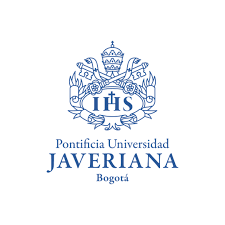
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Tratamiento de Datos y Machine Learning con PySpark**

Autor: Daniel Felipe Castro Moreno

Fecha de Inicio: 16/04/2026

Fecha actual: 22/04/2026

## **Problemática**

Se tiene que el tratamiento del agua debe ser indispensable para garantizar la pureza y la calidad. Uno de los elementos significativos es aplicar los conceptos de los Procesamientos de Datos en Alto Volúmen para solucionar este tipo de problemas que afectan la salud publica. El presente ejemplo tiene como propósito tener en cuenta una metodogología para aplicar el PAVD para solucionar o diagnósticar la calidad del agua en la INDIA.

## **Objetivo**

Implementar modelos de predicción utilizando la biblioteca de aprendizaje automático MLlib PySpark, con el fin de explorar y aplicar técnicas de IA en entornos de procesamiento con alto volúmen de datos.


## **Metodología**

1. Importación de bibliotecas y levantamiento de sesión Spark
2. Importación de los datos (datos en diferentes formatos)
3. Preprocesamiento y limpieza de valores nulos, cambio de datos, EDA, medidas estadísticas.
4. Entrenamiento de modelos: RL (MLlib), tensores (KERAS); la idea es predecir la calidad del agua en la INDIA.
5. Evaluación de los modelos: medidas de rendimiento como precision, accuracy, recall, F1 Score, entre otras.
6. Se tiene como referencia de la calidad de los parámetros del agua, la referencia: https://www.intechopen.com/chapters/69568

## **1. Importación de bibliotecas**
En esta fase, se importan todas las bibliotecas necesarias para la manipulación de datos a gran escala, el análisis estadístico y la visualización gráfica, y se levanta la sesión Spark estableciendo el punto de entrada para el procesamiento distribuido.

Esto permite que el entorno de ejecución tenga las herramientas de Python estándar (Pandas, NumPy) para el análisis local y la potencia de PySpark para el manejo del Big Data, configurando específicamente los recursos del sistema y las variables de entorno para una integración fluida con el clúster.

In [1]:
# Levantamiento de variables de entorno pip
import os #---> Para interacción con el sistema operativo
import sys #---> Para recursos del sistema
sys.path.append('/usr/lib/python3/dist-packages/') # Agregar ruta a la lista de directorios de módulos
import pandas as pd #---> Para graficar objetos y dataframe
import numpy as np #---> Para algebra matricial
import matplotlib.pyplot as plt #---> Para formatos de gráficas
import seaborn as sns #---> Para estadística y graficar

In [2]:
# Importación de bibliotecas especializadas
from pylab import * #---> Para funciones de trazado y cálculo numérico
import findspark #---> Para librerias de Apache Spark
findspark.init('/Almacen/Spark') #---> Inicializar la ubicación de Spark en el sistema
import pyspark.sql.functions as F #---> Para funciones de manipulación de columnas SQL
from pyspark import SparkConf, SparkContext #---> Para configurar y crear el contexto de Spark
from pyspark.sql import SQLContext #---> Para trabajar con datos estructurados
from pyspark.sql import SparkSession #---> Punto de entrada principal para Spark SQL
from pyspark.sql.types import * #---> Para definir esquemas y tipos de datos
from pyspark.ml.feature import Imputer #---> Para imputación en tratamiento de nulos

### Levantamiento de sesión SPARK

In [3]:
configura = SparkConf() #---> Prepara los ajustes del programa
configura.setAppName("Calidad_Agua_Castro") #---> Nombre del proyecto
sparkCastro = SparkSession.builder.config(conf=configura).getOrCreate() #---> Crear la sesión de Spark
SQLContext(sparkContext=sparkCastro.sparkContext, sparkSession=sparkCastro) #---> Habilita el uso de tablas y lenguaje SQL
sparkContextoCastro = sparkCastro.sparkContext.getOrCreate() #---> Conecta el contexto
print("Sesion creada: sparkCastro")
sparkCastro #---> Despliega la información y el estado actual de la sesión

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/28 23:18:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/28 23:18:02 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/04/28 23:18:02 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


Sesion creada: sparkCastro


## **2. Carga de Datos**
En esta etapa, se realiza la ingesta del conjunto de datos externo mediante el lector de Spark, configurando la detección de encabezados para estructurar correctamente el DataFrame. Debido a la magnitud del archivo waterquality.csv, se ejecuta una visualización limitada de los primeros registros para validar la integridad de la carga y la disposición de las columnas sin comprometer la memoria del sistema.

In [4]:
# Se crea un dataframe pyspark realizando la lectura del archivo separado por comas con encabezado
df00 = sparkCastro.read.format("csv").option("header", "true").load("waterquality.csv") # Cargar datos
df00.show() # Mostrar primeros 5 debido al alto volumen de datos

+------------+--------------------+--------------+----+---+---+------------+----+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|         STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+--------------+----+---+---+------------+----+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|   MAHARASHTRA|29.2|6.4|8.1|         735| 3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|   MAHARASHTRA|24.5|  6|  8|         270| 3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|   MAHARASHTRA|25.8|5.5|7.8|         355| 4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|   MAHARASHTRA|24.8|5.5|7.8|         371| 5.6|               3.55|            90|           283|
|        2183|GODAVARI RIVER AT...|   MAHARASHTRA|25.7|5.7|7.9|         294|

#### **Análisis Preliminar de Calidad del Agua**

##### **Consistencia y Distribución Geográfica**
*   **Alcance:** En esta primera aproximación, los datos cubren estaciones ubicadas en estados como **Maharashtra y Andhra Pradesh.
*   **Integridad:** En la muestra inicial de 20 registros, no se detectan valores nulos a simple vista. Los parámetros de calidad parecen seguir una estructura numérica, aunque es necesario verificar la consistencia de los tipos de datos en el resto del conjunto.

##### **Indicadores de Contaminación**
*   **Demanda Bioquímica de Oxígeno (BOD):** Se identifican focos de contaminación orgánica. Mientras algunas estaciones presentan niveles bajos (1.7), puntos específicos como las estaciones 2361, 2362, 2181 y 2180 muestran valores superiores a 10, sugiriendo una carga orgánica elevada que demanda mayor oxígeno.
*   **Oxígeno Disuelto (DO):** Los niveles observados fluctúan entre 4.5 y 7.0 mg/L. El registro de 4.5 es notable por su correlación con los niveles altos de BOD, lo que podría indicar una presión sobre el ecosistema acuático en esos puntos.
*   **pH:** La tendencia en la muestra es alcalina (7.5 a 8.5). Destaca la estación 2361 con un pH de 9.0, un nivel que marca un límite relevante para el equilibrio químico del agua.

##### **Contaminación Bacteriológica**
*   **Coliformes:** Se observa una disparidad considerable entre registros. Mientras algunas zonas de Maharashtra mantienen niveles de Coliformes Totales moderados (70-340), en estaciones de Andhra Pradesh como la 2362 los valores se incrementan hasta 700, señalando una posible incidencia de descargas residuales.

##### **Conductividad y Nutrientes**
*   **Conductividad:** El rango es amplio (178 a 925 µS/cm), lo que sugiere variaciones en la mineralización del agua dependiendo de la actividad circundante a la estación.
*   **Nitratos:** Los valores son generalmente bajos en esta muestra, con picos aislados (9 y 6.9) en estaciones como la 2182 y 2159, posibles indicadores de escorrentía en esas zonas.

La muestra revela una calidad de agua heterogénea, donde ciertos puntos exhiben niveles de contaminación orgánica y bacteriológica más acentuados, lo que justifica un análisis más profundo de la totalidad del archivo waterquality.csv.

## **3. Análisis y Preparación de Datos**

Se presentan datos (csv) con los diferentes parámetros de los ríos de la India. Cada parámetro es el promedio de los valores medidos en un período de tiempo. Los datos han sido extraidos de la web oficial de la India (RiverIndia)

Realizar un Análisis Exploratorio de Datos (EDA) en PySpark es un paso necesario para entender la calidad, estructura y relaciones de tus datos antes de aplicar modelos de Machine Learning.

A diferencia de Pandas, en Spark debemos ser conscientes de que trabajamos con computación distribuida, por lo que algunas operaciones pueden ser costosas.

### **Inspección de Estructura y Tipos**
El primer paso es verificar que Spark haya interpretado correctamente los datos (esquema) y observar una pequeña muestra.

In [5]:
# Visualizar la estructura jerárquica y tipos de datos de las columnas
df00.printSchema()

root
 |-- STATION CODE: string (nullable = true)
 |-- LOCATIONS: string (nullable = true)
 |-- STATE: string (nullable = true)
 |-- TEMP: string (nullable = true)
 |-- DO: string (nullable = true)
 |-- pH: string (nullable = true)
 |-- CONDUCTIVITY: string (nullable = true)
 |-- BOD: string (nullable = true)
 |-- NITRATE_N_NITRITE_N: string (nullable = true)
 |-- FECAL_COLIFORM: string (nullable = true)
 |-- TOTAL_COLIFORM: string (nullable = true)



In [6]:
# Conocimiento de las columnas
df00.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']

#### **Diccionario de Parámetros del Dataset**

Para el análisis de la calidad del agua en el archivo **waterquality.csv**, se definen las siguientes variables:

| Variable | Descripción Técnica | Observaciones / Unidad |
| :--- | :--- | :--- |
| **STATION CODE** | Identificador único de la estación. | Código de medida. |
| **LOCATIONS** | Punto geográfico de muestreo. | Ubicación del río. |
| **STATE** | División política en la India. | Estado federado. |
| **TEMP** | Temperatura termodinámica del agua. | Medido en **°C**. |
| **DO** | Oxígeno Disuelto. | **mg/L**. A mayor nivel, mejor calidad. |
| **pH** | Potencial de Hidrógeno. | Medida de acidez o alcalinidad (0-14). |
| **CONDUCTIVITY** | Conductividad eléctrica. | Capacidad del agua para conducir corriente. |
| **BOD** | Demanda Bioquímica de Oxígeno. | Indica carga orgánica; a mayor BOD, más contaminación. |
| **NITRATE_N_NITRITE_N** | Concentración de Nitratos y Nitritos. | **mg/L**. Niveles altos provocan eutrofización (algas). |
| **FECAL_COLIFORM** | Coliformes fecales. | Presencia de bacterias de origen intestinal. |
| **TOTAL_COLIFORM** | Coliformes totales. | *Variable a eliminar: No aporta valor predictivo.* |

In [7]:
# Contar el total de registros para dimensionar el dataset completo
totalRegistros = df00.count()
print(f"Total de registros en el dataset: {totalRegistros}")

Total de registros en el dataset: 534


### **Resumen Estadístico (Perfilado)**
Este paso ayuda a identificar el rango de los datos, promedios y posibles valores atípicos (*outliers*).

In [8]:
for valor in df00.columns: # Recorre cada columna del dataframe
  df00.describe([valor]).show() # Mostrar las estadísticas de cada columna

+-------+-----------------+
|summary|     STATION CODE|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|             1023|
|    max|               41|
+-------+-----------------+

+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                534|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+



+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           534|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+



+-------+------------------+
|summary|              TEMP|
+-------+------------------+
|  count|               534|
|   mean|25.241398865784515|
| stddev|3.4480130875026624|
|    min|              10.5|
|    max|                NA|
+-------+------------------+

+-------+-----------------+
|summary|               DO|
+-------+-----------------+
|  count|              534|
|   mean|6.389812030075193|
| stddev|1.622861728733986|
|    min|                0|
|    max|               NA|
+-------+-----------------+

+-------+------------------+
|summary|                pH|
+-------+------------------+
|  count|               534|
|   mean|  7.79812734082397|
| stddev|0.6499503911518124|
|    min|              13.2|
|    max|               9.1|
+-------+------------------+

+-------+------------------+
|summary|      CONDUCTIVITY|
+-------+------------------+
|  count|               534|
|   mean| 684.9761904761905|
| stddev|1769.3297602834873|
|    min|               100|
|    max|           

### **Análisis de las estadísticas**
1. **Presencia de valores no numéricos ("NA")**

- Se observa que en casi todas las variables numéricas principales (TEMP, DO, CONDUCTIVITY, BOD, etc.), el valor máximo aparece como "NA".

2. **Inconsistencias en los rangos (Outliers y Errores)**

- STATION CODE: El valor mínimo es 1023 y el máximo es 41. Esto confirma nuevamente que Spark está ordenando los datos como texto (donde "4" es mayor que "1"), reforzando la necesidad de cambiar el tipo de dato.

- pH: El valor mínimo reportado es 13.2 y el máximo 9.1. Un pH de 13.2 es extremadamente básico (similar a la lejía), lo cual es inusual para agua de río y sugiere errores de medición o de entrada de datos.

- Oxígeno Disuelto (DO): El valor mínimo es 0, lo que indica condiciones de muerte biológica en algunos puntos de muestreo.

3. **Dispersión Extrema en Contaminación**

- BOD (Demanda Biológica de Oxígeno): Con una media de 5.34 pero una desviación estándar de 8.5, los datos están muy dispersos. Hay sitios con agua limpia (0.2) y otros con cargas orgánicas muy pesadas.

- Coliformes (FECAL/TOTAL): La desviación estándar es masiva en comparación con la media. Esto indica que el dataset contiene valores extremos (hotspots de contaminación fecal) que sesgan el promedio significativamente.

### **Manejo de Valores Faltantes (Nulls)**
Proceso de identificación, cuantificación y tratamiento de registros incompletos para asegurar la calidad y consistencia estadística del dataset.

In [9]:
# Cantidad de Valores Nulos, NaN o cadenas "NA"
df00.select([F.count(F.when(F.isnan(c) | F.col(c).isNull() | (F.col(c) == "NA"), c)).alias(c) for c in df00.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   5|  2|  0|          30|  6|                  2|            82|            39|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



### **Análisis de Nulos y decisiones**
Este resultado confirma que el dataset tiene una contaminación de datos. Aunque las columnas deberían ser numéricas, la presencia de la cadena de texto "NA" obligó a Spark a interpretar todo como String, ocultando la verdadera cantidad de valores nulos. Para limpiar el dataset waterquality.csv por completo y dejarlo listo para el análisis, se sigue una estrategia de limpieza y tipado fuerte. Se determina además que "TOTAL_COLIFORM" no es útil para el anál

#### **Tratamiento de datos**

In [10]:
df00.dtypes # Mostrar tipos de datos

[('STATION CODE', 'string'),
 ('LOCATIONS', 'string'),
 ('STATE', 'string'),
 ('TEMP', 'string'),
 ('DO', 'string'),
 ('pH', 'string'),
 ('CONDUCTIVITY', 'string'),
 ('BOD', 'string'),
 ('NITRATE_N_NITRITE_N', 'string'),
 ('FECAL_COLIFORM', 'string'),
 ('TOTAL_COLIFORM', 'string')]

In [11]:
# Se procede a cambiar los tipos de datos
df00 = df00.withColumn('STATION CODE', df00['STATION CODE'].cast(IntegerType()))
df00 = df00.withColumn('TEMP', df00['TEMP'].cast(FloatType()))
df00 = df00.withColumn('DO', df00['DO'].cast(FloatType()))
df00 = df00.withColumn('pH', df00['pH'].cast(FloatType()))
df00 = df00.withColumn('CONDUCTIVITY', df00['CONDUCTIVITY'].cast(IntegerType()))
df00 = df00.withColumn('BOD', df00['BOD'].cast(FloatType()))
df00 = df00.withColumn('NITRATE_N_NITRITE_N', df00['NITRATE_N_NITRITE_N'].cast(FloatType()))
df00 = df00.withColumn('FECAL_COLIFORM', df00['FECAL_COLIFORM'].cast(IntegerType()))
df00 = df00.withColumn('TOTAL_COLIFORM', df00['TOTAL_COLIFORM'].cast(IntegerType()))
df00.dtypes

[('STATION CODE', 'int'),
 ('LOCATIONS', 'string'),
 ('STATE', 'string'),
 ('TEMP', 'float'),
 ('DO', 'float'),
 ('pH', 'float'),
 ('CONDUCTIVITY', 'int'),
 ('BOD', 'float'),
 ('NITRATE_N_NITRITE_N', 'float'),
 ('FECAL_COLIFORM', 'int'),
 ('TOTAL_COLIFORM', 'int')]

|Variables|Tipo| Justificación|
|-|-|-
|LOCATIONS, STATE|String|Son cadenas de texto y datos categóricos que representan nombres de lugares, solo sirven para identificar|
|TEMP, DO, pH, BOD, NITRATE_N_NITRITE_N| Float|Son números con decimales que representan medidas físicas. Se deben poder realizar operaciones aritméticas y obtener promedios precisos|
|STATION CODE, CONDUCTIVITY, FECAL_COLIFORM, TOTAL_COLIFORM|Integer|Son números enteros para conteos. Este tipo es más ligero para el sistema porque ocupa menos memoria y acelera el procesamiento|

In [12]:
#Se elimina la columna TOTAL_COLIFORM
df01 = df00.drop('TOTAL_COLIFORM')
df01.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM']

#### **Estrategia de Depuración: Imputación y Filtrado**
Tras la conversión de tipos (casting), los valores identificados previamente como "NA" han sido transformados automáticamente por Spark en valores nulos reales (`null`). Para tratar estos vacíos, se aplican dos criterios diferenciados:

1.  **Imputación por Tendencia Central (Media):** Para las variables fisicoquímicas con una tasa de nulos baja (como TEMP, DO, pH, BOD y NITRATE_N_NITRITE_N), se opta por la imputación mediante la media. Esto permite preservar el tamaño de la muestra sin alterar significativamente la distribución de las variables.
2.  **Filtrado por Relevancia (Eliminación):** En el caso de FECAL_COLIFORM, la variable presenta una pérdida de datos cercana al 15% (82 registros). Debido a la alta variabilidad bacteriológica, imputar estos datos podría introducir sesgos artificiales considerables. Por tanto, se procede con la eliminación de filas (*listwise deletion*) para garantizar que el modelo trabaje solo con evidencia empírica real en esta dimensión.

In [13]:
# Definición de columnas para imputación (Parámetros fisicoquímicos)
cols_a_imputar = ["TEMP", "DO", "pH", "BOD", "NITRATE_N_NITRITE_N", "CONDUCTIVITY"]

# Configuración del Imputer utilizando la media como estrategia
imputador = Imputer(
    inputCols=cols_a_imputar, 
    outputCols=cols_a_imputar
).setStrategy("mean")

# Aplicación de la imputación al DataFrame
df01 = imputador.fit(df01).transform(df01)

# Eliminación de registros con nulos remanentes en indicadores bacteriológicos
df01 = df01.na.drop(subset=["FECAL_COLIFORM"])

# Validación
df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull() | (F.col(c) == "NA"), c)).alias(c) for c in df01.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+



In [14]:
for valor in df01.columns: # Recorre cada columna del dataframe
  df01.describe([valor]).show() # Mostrar las estadísticas de cada columna

+-------+------------------+
|summary|      STATION CODE|
+-------+------------------+
|  count|               452|
|   mean|2056.7676991150443|
| stddev| 748.0975614434988|
|    min|                11|
|    max|              3330|
+-------+------------------+

+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                452|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+

+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           452|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+

+-------+------------------+
|summary|              TEMP|
+-------+------------------+
|  count|               452|
|   mean| 25.45044243019239|
| stddev|3.3296790507955496|
|    min|              10.5|
|    max|              33.8|
+-------+

#### **Validación final**
Se valida que todas las estadísticas son coherentes con el conjunto de datos.

### **Visualización de Datos**
Generación de representaciones gráficas mediante el muestreo y conversión de datos distribuidos a formatos locales para identificar patrones, tendencias y correlaciones visuales.

In [15]:
# Se crea una vista para ser usada en las visualizaciones
df00.createOrReplaceTempView("df00_sql")
df01 = sparkCastro.sql('''Select * from df00_sql where TEMP is not null and
    DO is not null and
    pH is not null and
    CONDUCTIVITY is not null and
    BOD is not null and
    NITRATE_N_NITRITE_N is not null and
    FECAL_COLIFORM is not null''')

In [16]:
# Se hace uso de la función LAMBDA para hacer el tratamiento/limpieza de los datos
df01.createOrReplaceTempView("df01_sql")

In [17]:
#Se crea una consulta por cada parámetro DO
do_parametro = sparkCastro.sql("Select DO from df01_sql")

In [18]:
#Se hace una consulta para crear el vector de la tabla por cada parámetro
do_parametro = do_parametro.rdd.map(lambda fila: fila.DO).collect()

# pH
ph_parametro = sparkCastro.sql("Select pH from df01_sql") #---> Consultar los valores de pH
ph_parametro = ph_parametro.rdd.map(lambda fila: fila.pH).collect() #---> Crear el vector de datos para pH

# CONDUCTIVITY
cond_parametro = sparkCastro.sql("Select CONDUCTIVITY from df01_sql") #---> Consultar los valores de conductividad
cond_parametro = cond_parametro.rdd.map(lambda fila: fila.CONDUCTIVITY).collect() #---> Crear el vector de datos para conductividad

# BOD
bod_parametro = sparkCastro.sql("Select BOD from df01_sql") #---> Consultar los valores de demanda biológica de oxígeno
bod_parametro = bod_parametro.rdd.map(lambda fila: fila.BOD).collect() #---> Crear el vector de datos para BOD

# NITRATE_N_NITRITE_N
nit_parametro = sparkCastro.sql("Select NITRATE_N_NITRITE_N from df01_sql") #---> Consultar los valores de nitratos y nitritos
nit_parametro = nit_parametro.rdd.map(lambda fila: fila.NITRATE_N_NITRITE_N).collect() #---> Crear el vector de datos para nitratos

# FECAL_COLIFORM
fecal_parametro = sparkCastro.sql("Select FECAL_COLIFORM from df01_sql") #---> Consultar los valores de coliformes fecales
fecal_parametro = fecal_parametro.rdd.map(lambda fila: fila.FECAL_COLIFORM).collect() #---> Crear el vector de datos para coliformes fecales

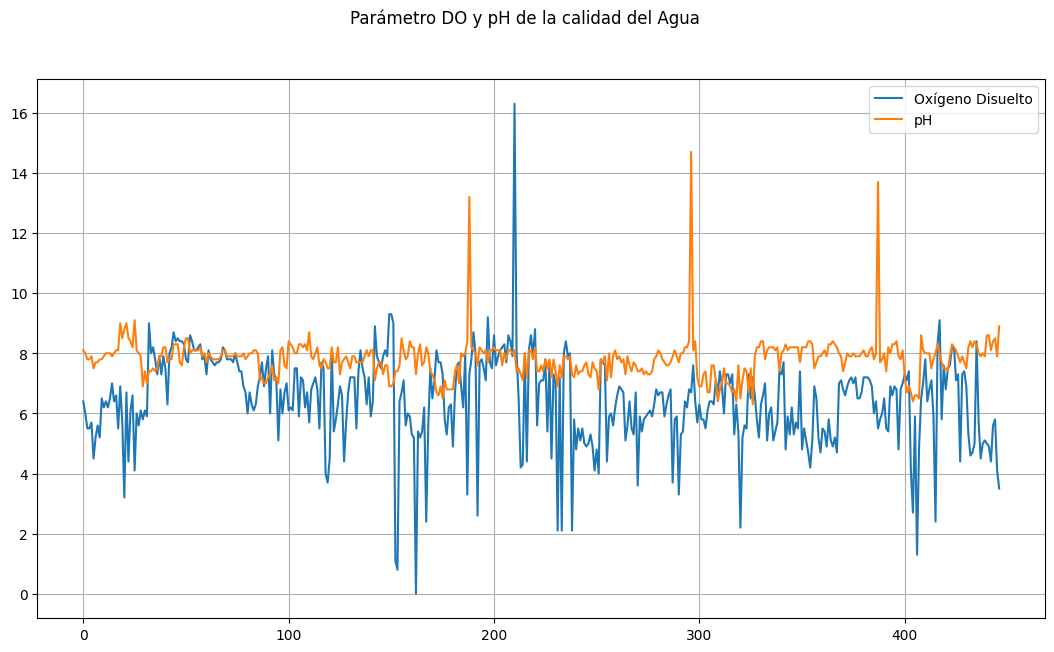

In [19]:
# Gráfica de los parámetros para conocer sus características: DO y PH
tam = len(do_parametro) #---> Cantidad total de datos a graficar
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k') #---> Lienzo y tamaño
ax1.plot(range(0,tam), do_parametro, label='Oxígeno Disuelto') #---> Línea para los valores de Oxígeno Disuelto
ax1.plot(range(0,tam), ph_parametro, label='pH') #---> Línea para los valores de pH
fig.suptitle('Parámetro DO y pH de la calidad del Agua') #---> Título principal a la gráfica
legend=ax1.legend() #---> Leyenda para identificar cada variable
plt.grid() #---> Activar la cuadrícula
plt.show()

La gráfica permite observar el comportamiento dinámico de la calidad del agua a través de las estaciones de muestreo procesadas.

##### **1. Estabilidad y Rango del pH**
*   **Comportamiento General:** El pH (línea naranja) exhibe una estabilidad notable en la mayor parte del dataset, manteniéndose predominantemente en el rango de 7.0 a 8.5, lo cual es típico de cuerpos de agua con ligera alcalinidad.
*   **Valores Atípicos (Outliers):** Se identifican tres picos positivos extremos que superan el valor de 13, situándose cerca de 14. Estos valores son químicamente inusuales para entornos naturales y sugieren errores de sensor o vertidos industriales masivos altamente cáusticos en puntos específicos de la muestra.

##### **2. Variabilidad del Oxígeno Disuelto (DO)**
*   **Fluctuaciones:** A diferencia del pH, el DO (línea azul) presenta una volatilidad constante, oscilando mayormente entre 4 y 9 mg/L. Esta variabilidad es indicativa de cambios en la temperatura, la velocidad del flujo y la actividad biológica entre estaciones.
*   **Zonas Críticas (Anoxia):** Se observan múltiples descensos pronunciados donde el DO cae por debajo de 2 mg/L, alcanzando incluso el valor de 0 (alrededor de la muestra 160). Estos puntos representan condiciones de anoxia, donde la vida acuática superior no es sostenible debido a la degradación extrema de la calidad hídrica.

##### **3. Interacción entre Parámetros**
*   **Pico Anómalo de DO:** Se registra un evento singular cerca de la muestra 210 donde el DO se dispara por encima de 16 mg/L. Este valor excede la saturación normal de oxígeno en condiciones estándar, lo que refuerza la presencia de anomalías en los datos o fenómenos locales de sobresaturación.
*   **Correlación Visual:** No se aprecia una correlación directa simple entre ambos parámetros; sin embargo, en los puntos donde el pH cae ligeramente por debajo de 7, el DO tiende a presentar inestabilidades más marcadas, lo que podría correlacionarse con zonas de alta carga orgánica.

La visualización confirma que, tras la limpieza de nulos, el dataset aún conserva valores atípicos extremos (outliers) que se alejan de la realidad biológica del agua. Para propósitos de modelado predictivo, se recomienda aplicar un tratamiento adicional de suavizado o eliminación de estos valores extremos para evitar sesgos en el aprendizaje del modelo.

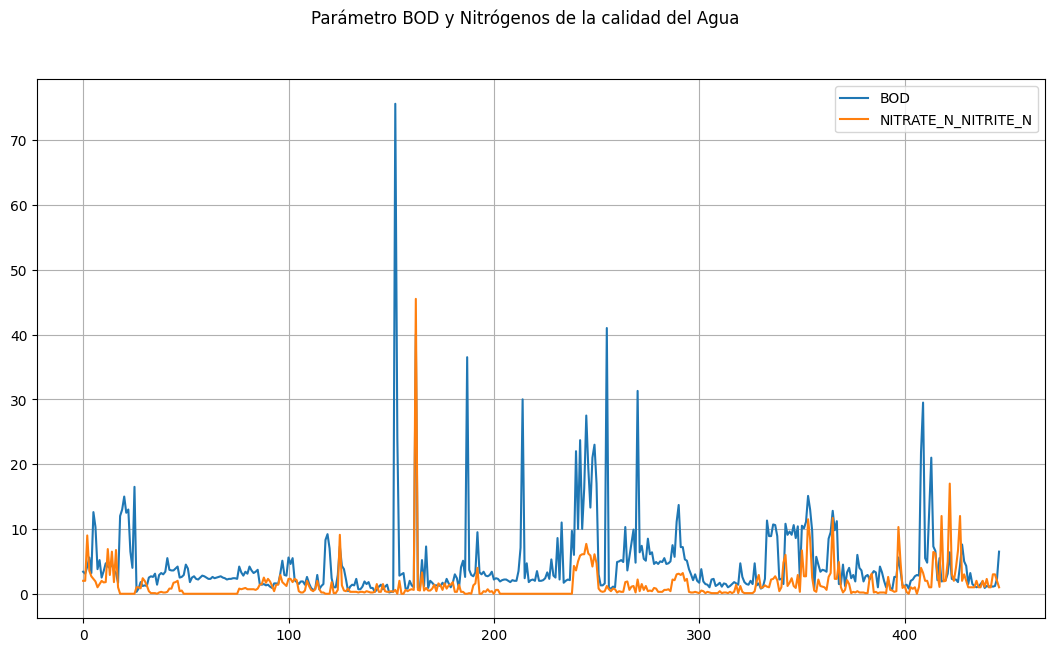

In [20]:
# Gráfica de los parámetros para conocer sus características: BOD y Nitrógenos
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), bod_parametro, label='BOD')
ax1.plot(range(0,tam), nit_parametro, label='NITRATE_N_NITRITE_N')
fig.suptitle('Parámetro BOD y Nitrógenos de la calidad del Agua')
legend=ax1.legend()
plt.grid()
plt.show()

La gráfica comparativa permite evaluar la carga de contaminantes orgánicos y nutrientes en el dataset.

##### **1. Comportamiento de la Carga Orgánica (BOD)**
*   **Tendencia Base:** La mayoría de los registros de BOD (línea azul) se mantienen en un rango bajo, generalmente por debajo de 10 mg/L. Esto sugiere que, en condiciones normales, la actividad microbiana para descomponer materia orgánica es moderada.
*   **Picos de Contaminación Crítica:** Se observan múltiples picos aislados de gran magnitud. El más prominente ocurre cerca de la muestra 150, alcanzando un valor superior a 70 mg/L. Este comportamiento es un indicador inequívoco de descargas masivas de residuos orgánicos o aguas residuales sin tratar en puntos específicos del río.

##### **2. Presencia de Nutrientes (Nitratos y Nitritos)**
*   **Estabilidad General:** La concentración de Nitrógeno (línea naranja) es predominantemente baja, manteniéndose cerca de 0 mg/L en amplios sectores del gráfico. Esto indica que la contaminación por fertilizantes o escorrentía agrícola no es un problema constante en todas las estaciones.
*   **Eventos de Eutrofización:** Existen repuntes significativos, destacando uno que supera los 45 mg/L poco después de la muestra 150. Niveles tan altos de nitratos pueden desencadenar el crecimiento acelerado de algas, degradando rápidamente la calidad hídrica.

##### **3. Correlación de Contaminantes**
*   **Sincronía de Picos:** Es notable que los picos más altos de ambas variables tienden a ocurrir en áreas cercanas del eje X (por ejemplo, entre las muestras 150-200 y cerca de la 420). Esto sugiere que existen estaciones de muestreo donde coinciden tanto la carga orgánica como la de nitratos, probablemente debido a vertidos complejos de origen industrial o urbano.
*   **Variabilidad Conjunta:** Al final de la serie (muestras 400-450), se observa un aumento en la frecuencia de picos para ambas variables, lo que denota una zona geográficamente más inestable o con mayor presión antropogénica.

La gráfica revela un ecosistema hídrico con episodios puntuales de contaminación severa. Mientras que los niveles promedio son manejables, los valores extremos (outliers) en BOD y Nitratos representan riesgos ambientales graves. Para el desarrollo del modelo, estos picos deben ser analizados con cuidado, ya que su gran desviación respecto a la media podría distorsionar la capacidad predictiva si no se tratan adecuadamente.

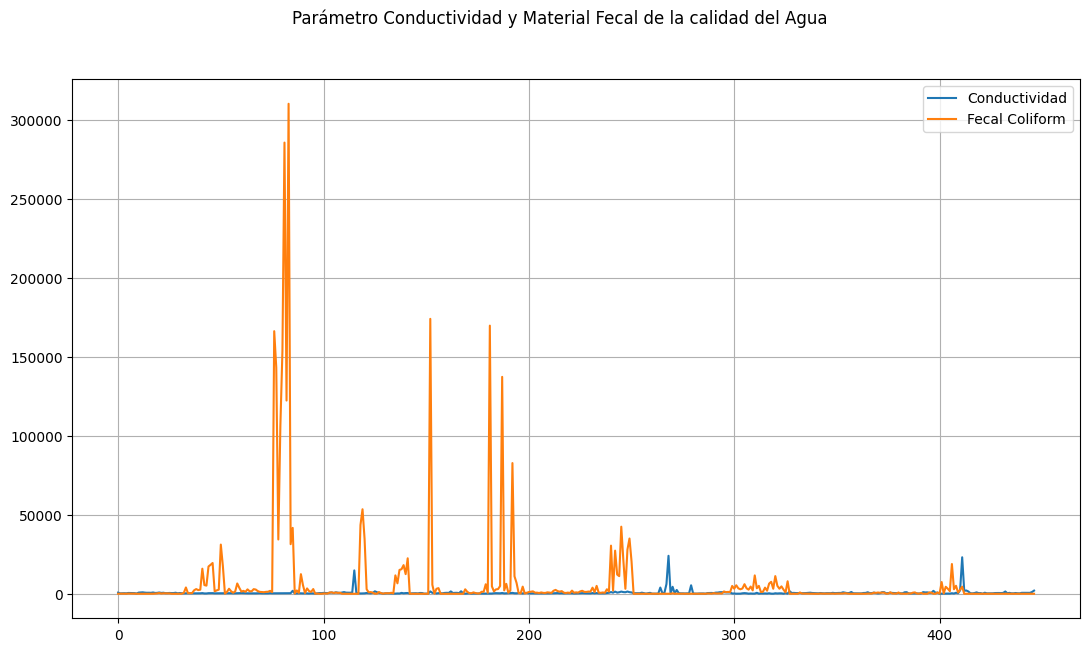

In [21]:
# Gráfica de los parámetros para conocer sus características: FC y Conductividad
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), cond_parametro, label='Conductividad')
ax1.plot(range(0,tam), fecal_parametro, label='Fecal Coliform')
fig.suptitle('Parámetro Conductividad y Material Fecal de la calidad del Agua')
legend=ax1.legend()
plt.grid()
plt.show()

La gráfica revela la dimensión sanitaria y de mineralización del estudio.

##### **1. Coliformes Fecales: niveles altos Fecales**
*   **Escala de Contaminación:** La variable de coliformes (línea naranja) domina la escala vertical, alcanzando picos alarmantes que superan las 300,000 unidades. Estos valores indican una contaminación bacteriológica extrema, probablemente vinculada a descargas de aguas residuales domésticas masivas y directas.
*   **Frecuencia de Brotes:** Se observan tres clusters principales de alta contaminación: el primero y más intenso entre las muestras 70-90, un segundo bloque entre 150-200, y picos menores recurrentes hacia el final de la serie. Esta intermitencia sugiere que la contaminación fecal es geográfica o temporalmente dependiente de asentamientos densamente poblados.

##### **2. Comportamiento de la Conductividad**
*   **Estabilidad Relativa:** La conductividad (línea azul) se mantiene en niveles bajos y constantes en comparación con la carga bacteriológica. La mayoría de los registros se sitúan cerca de la base del gráfico.
*   **Picos de Mineralización:** Existen incrementos puntuales, como el registrado cerca de la muestra 270 y otro hacia la 410, donde la conductividad se eleva notablemente. Estos eventos pueden estar relacionados con la presencia de sales disueltas o vertidos industriales químicos que no necesariamente coinciden con los focos de contaminación biológica.

##### **3. Disociación de los Parámetros**
*   **Independencia de Fuentes:** Hay que notar que los picos máximos de Coliformes Fecales no coinciden con los picos de Conductividad. Por ejemplo, en el intervalo de la muestra 80, donde la carga fecal es máxima, la conductividad permanece plana.
*   **Interpretación:** Esto sugiere que las fuentes de contaminación son distintas: los coliformes provienen de desechos orgánicos/sanitarios, mientras que los picos de conductividad responden a factores geológicos o vertidos inorgánicos específicos.

La visualización subraya que la mayor amenaza para la calidad hídrica en este dataset es de carácter bacteriológico. Mientras que la conductividad se mantiene en rangos mayormente estables, la presencia de coliformes fecales alcanza niveles que representan un riesgo real para la salud pública. Para el modelo de predicción, esta variable será probablemente el indicador más difícil de normalizar debido a su varianza extrema.

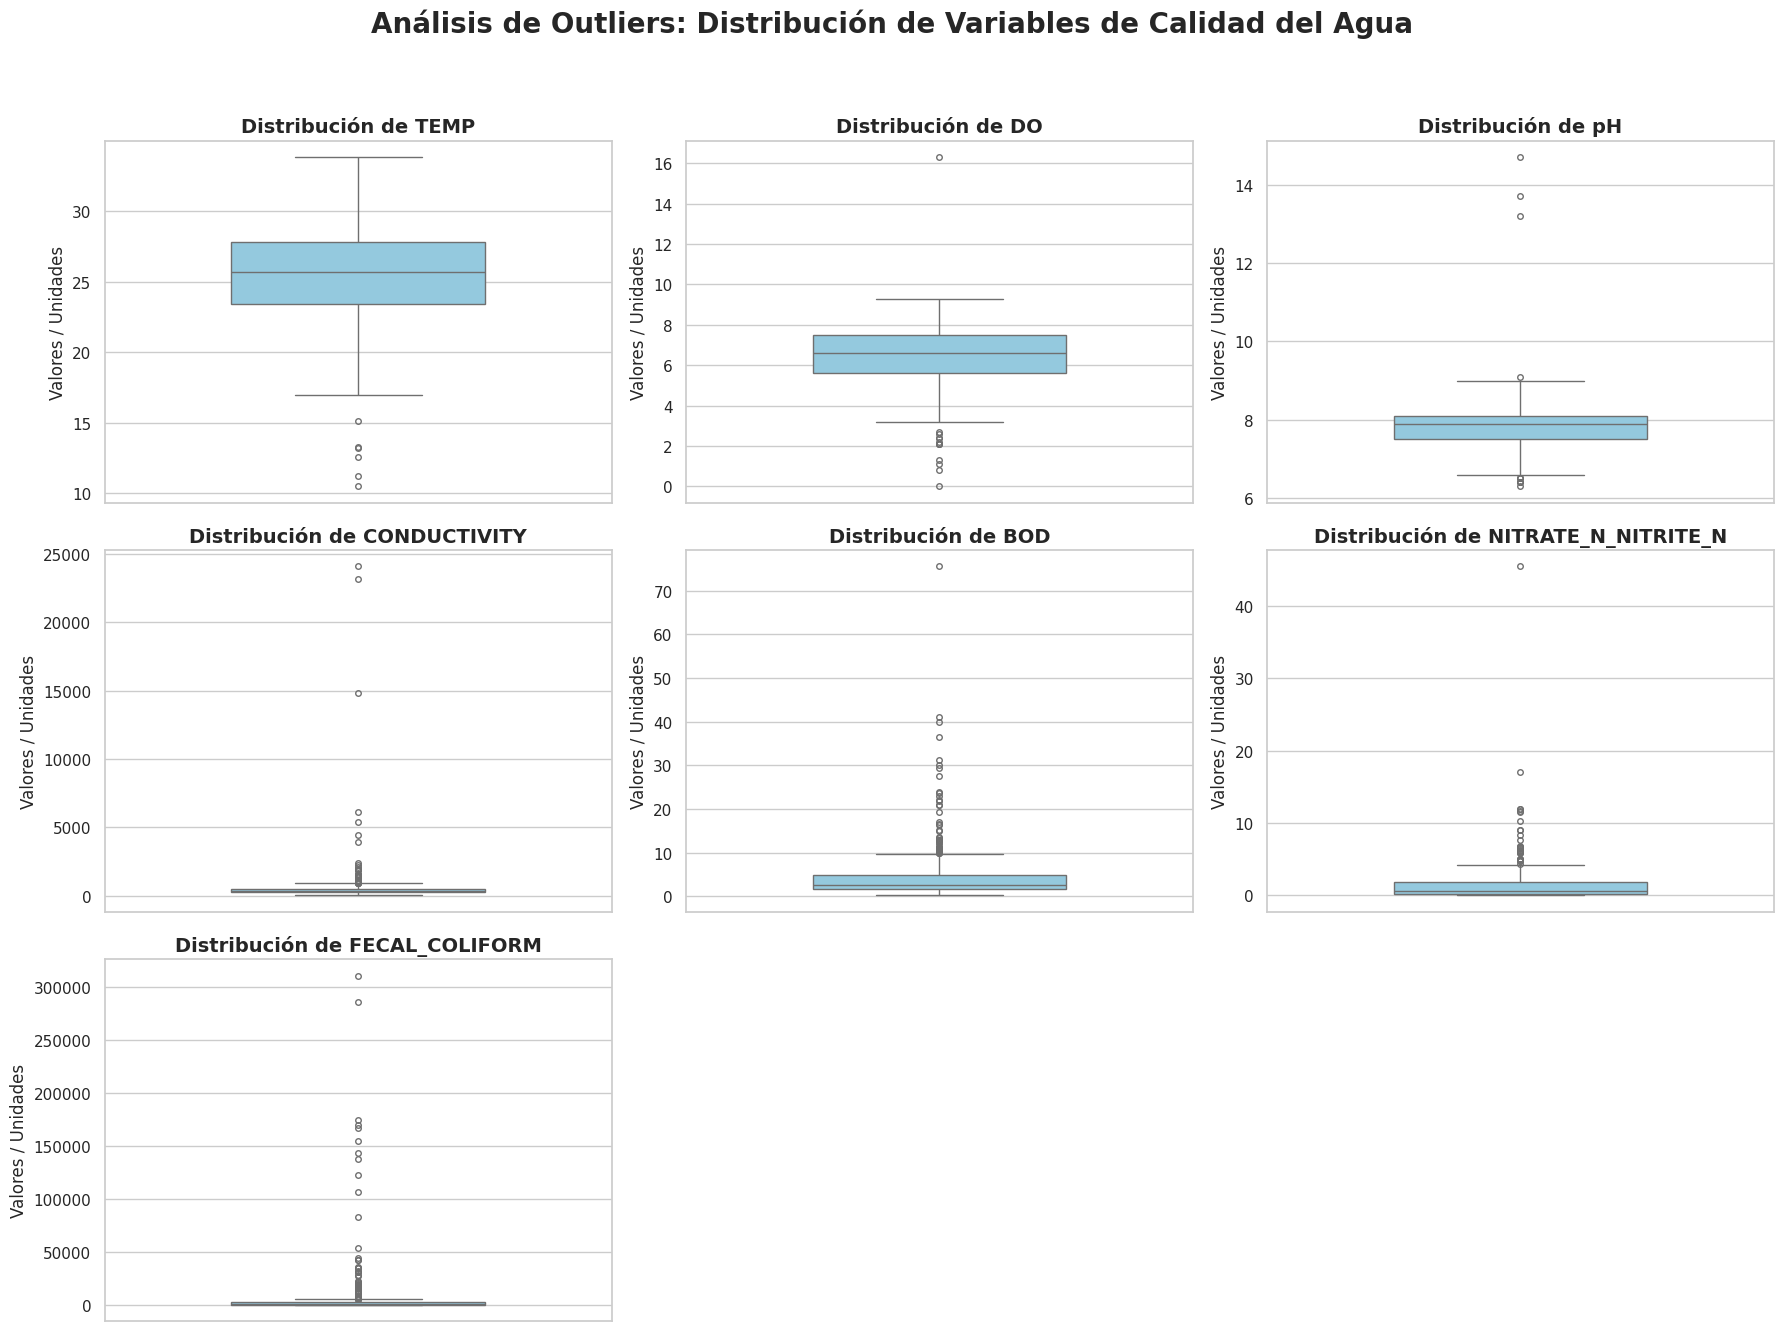

In [22]:
# Convertir una muestra o el DF limpio a Pandas para visualización
pd_df = df01.toPandas()

# Configuración estética
sns.set_theme(style="whitegrid")
columnas_boxplot = ["TEMP", "DO", "pH", "CONDUCTIVITY", "BOD", "NITRATE_N_NITRITE_N", "FECAL_COLIFORM"]

# Crear la figura con subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 14))
fig.suptitle('Análisis de Outliers: Distribución de Variables de Calidad del Agua', fontsize=20, fontweight='bold')

# Iterar para generar cada gráfico
for i, col in enumerate(columnas_boxplot):
    row, ax_col = divmod(i, 3)
    sns.boxplot(y=pd_df[col], ax=axes[row, ax_col], color="skyblue", width=0.5, fliersize=4)
    axes[row, ax_col].set_title(f'Distribución de {col}', fontsize=14, fontweight='bold')
    axes[row, ax_col].set_ylabel('Valores / Unidades')

# Eliminar subplots vacíos si sobran
for j in range(len(columnas_boxplot), 9):
    row, ax_col = divmod(j, 3)
    fig.delaxes(axes[row, ax_col])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Este análisis estadístico de cajas y bigotes permite identificar la dispersión real de los datos y la severidad de los valores atípicos en el dataset de calidad del agua.

##### **1. Identificación de Asimetría y Valores Extremos**
*   **Concentración de Datos:** En la mayoría de las variables, como CONDUCTIVITY, BOD, NITRATE_N_NITRITE_N y FECAL_COLIFORM, la caja que contiene el 50% de los datos se encuentra comprimida en la parte inferior del eje. Esto indica que la gran mayoría de las muestras presentan niveles bajos, pero existen eventos de contaminación que disparan los valores a escalas desproporcionadas.
*   **Outliers:** Las variables microbiológicas (FECAL_COLIFORM) y químicas (BOD, NITRATE) muestran puntos aislados que se alejan drásticamente de la media. Estos valores representan situaciones atípicas de vertidos o fallos en la medición que pueden sesgar cualquier modelo predictivo si no son tratados adecuadamente.

##### **2. Variables con Distribución más Estable**
*   **Temperatura y pH:** La TEMP y el pH presentan cajas más expandidas y centradas, lo que sugiere una distribución más cercana a la normalidad. Sin embargo, en el pH se observan valores superiores a 13, lo cual es químicamente incompatible con la vida fluvial y confirma la presencia de errores en la recolección de datos.
*   **Oxígeno Disuelto (DO):** El DO muestra una mediana saludable, pero con una cola inferior de valores cercanos a cero, confirmando zonas con anoxia (falta de oxígeno) total.

##### **3. Impacto en el Modelado de Datos**
*   **Sesgo Estadístico:** Debido a que el rango de los coliformes llega a 300,000 mientras que el pH varía entre 6 y 9, el modelo de Machine Learning podría dar una importancia injustificada a las variables con magnitudes mayores.
*   **Riesgo de Inestabilidad:** Los valores extremos identificados en los boxplots actuarán como "ruido", impidiendo que los algoritmos de predicción identifiquen los patrones normales de la calidad del agua.

### **Tratamiento de outliers, normalización y escalado**

Para mitigar los problemas identificados en los boxplots, se procederá con las siguientes técnicas de ingeniería de datos:

1.  **Winsorización (Capping):** Se limitarán los valores extremos al percentil 95 o 99. Esto significa que los valores alarmantes (como los 300,000 en coliformes) se ajustarán a un valor máximo razonable para que sigan representando "alta contaminación" sin romper la escala estadística del modelo.
2.  **Filtrado de Valores Imposibles:** Se eliminarán manualmente los registros de `pH` superiores a 14 o inferiores a 0, tratándolos como errores de sensor irrecuperables.

In [23]:
# Winsorización (Capping): limita los valores extremos al percentil 1-99
def treat_outliers(df, col_name):
    quantiles = df.approxQuantile(col_name, [0.01, 0.99], 0.01)
    lower_limit = quantiles[0]
    upper_limit = quantiles[1]
    return df.withColumn(col_name,
        F.when(F.col(col_name) < lower_limit, lower_limit)
         .when(F.col(col_name) > upper_limit, upper_limit)
         .otherwise(F.col(col_name))
    )

# Lista de columnas con alta varianza identificadas en los boxplots
cols_con_outliers = ["BOD", "CONDUCTIVITY", "FECAL_COLIFORM", "NITRATE_N_NITRITE_N"]

# se inicializa df02 desde df01 y se actualiza en cada iteración
df02 = df01
for col in cols_con_outliers:
    df02 = treat_outliers(df02, col)  # ← corregido: actualiza df02

# Filtrado de valores físicamente imposibles en pH
df02 = df02.filter((F.col('pH') >= 0) & (F.col('pH') <= 14))

print(f'Registros tras limpieza: {df02.count()}')
df02.select(cols_con_outliers).describe().show()

Registros tras limpieza: 446


26/04/28 23:18:43 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-------------------+------------------+------------------+-------------------+
|summary|                BOD|      CONDUCTIVITY|    FECAL_COLIFORM|NITRATE_N_NITRITE_N|
+-------+-------------------+------------------+------------------+-------------------+
|  count|                446|               446|               446|                446|
|   mean| 4.6417040265929534| 625.1412556053812| 6733.242152466368| 1.4176233172283044|
| stddev|  6.395026869181553|1774.1093996776215|28597.946357235924|  2.926762627295797|
|    min|0.20000000298023224|              39.0|               0.0|                0.0|
|    max|   75.5999984741211|           24062.0|          310417.0|               45.5|
+-------+-------------------+------------------+------------------+-------------------+



## **4. Entrenamiento de modelos**
El objetivo principal de esta fase es la construcción de un Índice de Calidad del Agua (ICA) mediante la ponderación de parámetros relevantes. Para lograrlo, se realizará lo siguiente:

1.  **Categorización de Parámetros:** Se asignará un puntaje de calidad (0 a 100) a cada variable individualmente (pH, Oxígeno Disuelto, Conductividad, etc.) basándose en umbrales científicos.
2.  **Generación de Variables Objetivo:** Estos puntajes permitirán crear una etiqueta de clasificación que el modelo intentará predecir.
3.  **Preparación del Dataset Final:** Se consolidarán estas nuevas columnas en el objeto df02 para alimentar los algoritmos de clasificación o regresión.

#### **Categorización por Parámetros Físicoquímicos**
Siguiendo los estándares citados en la literatura técnica (IntechOpen), se crean funciones de rango que normalizan la calidad del agua. Un valor de 100 representa una condición óptima (Agua Dulce/Excelente), mientras que valores menores indican niveles crecientes de contaminación o dureza. La información de la literatura se resume en la siguiente tabla:

| Parámetro | Columna Destino | Puntaje | Rango de Valor | Descripción de Calidad |
| :--- | :--- | :---: | :--- | :--- |
| **pH** | `qrPH` | **100** | $7.0 \le \text{pH} \le 8.5$ | Óptimo (Agua Dulce) |
| | | **80** | $6.8-6.9$ o $8.5-8.6$ | Buena (Ligera desviación) |
| | | **60** | $6.7-6.8$ o $8.6-8.8$ | Moderada |
| | | **40** | $6.5-6.7$ o $8.8-9.0$ | Baja |
| | | **0** | $< 6.5$ o $> 9.0$ | Inadecuada |
| **Oxígeno Disuelto (DO)** | `qrDO` | **100** | $\ge 6.0$ | Excelente oxigenación |
| | | **80** | $5.1 - 5.9$ | Buena |
| | | **60** | $4.1 - 5.0$ | Moderada |
| | | **40** | $3.0 - 4.0$ | Baja (Estrés biótico) |
| | | **0** | $< 3.0$ | Inadecuada (Anoxia) |
| **Conductividad (COND)** | `qrCOND` | **100** | $0 - 75$ | Muy pura / Suave |
| | | **80** | $76 - 150$ | Moderada |
| | | **60** | $151 - 225$ | Dura |
| | | **40** | $226 - 300$ | Muy dura |
| | | **0** | $> 300$ | Inadecuada (Exceso mineral) |
| **BOD** | `qrBOD` | **100** | $< 3.0$ | Muy Limpia |
| | | **80** | $3.0 - 5.9$ | Contaminación leve |
| | | **60** | $6.0 - 79.9$ | Contaminación moderada |
| | | **40** | $80.0 - 124.9$ | Contaminación severa |
| | | **0** | $\ge 125.0$ | Inadecuada (Agua residual) |
| **Nitratos/Nitritos (NN)** | `qrNN` | **100** | $0 - 19.9$ | Calidad excelente |
| | | **80** | $20.0 - 49.9$ | Buena |
| | | **60** | $50.0 - 99.9$ | Moderada |
| | | **40** | $100.0 - 199.9$ | Riesgo de salud |
| | | **0** | $\ge 200.0$ | Inadecuada |
| **Coliformes Fecales** | `qrFecal` | **100** | $0 - 4.9$ | Potable (Sin rastro fecal) |
| | | **80** | $5.0 - 49.9$ | Contaminación leve |
| | | **60** | $50.0 - 499.9$ | Contaminación moderada |
| | | **40** | $500.0 - 999.9$ | Contaminación alta |
| | | **0** | $\ge 1000.0$ | Inadecuada (Riesgo sanitario) |

In [24]:
# Rango de calidad según el pH
# El rango óptimo se sitúa entre 7 y 8.5
df02 = df01.withColumn("qrPH", F.when((df01.pH >= 7) & (df01.pH <= 8.5), 100)
       .when(((df01.pH >= 6.8) & (df01.pH < 6.9)) | ((df01.pH > 8.5) & (df01.pH < 8.6)), 80)
       .when(((df01.pH >= 6.7) & (df01.pH < 6.8)) | ((df01.pH >= 8.6) & (df01.pH < 8.8)), 60)
       .when(((df01.pH >= 6.5) & (df01.pH < 6.7)) | ((df01.pH >= 8.8) & (df01.pH < 9.0)), 40)
       .otherwise(0))

# Rango de calidad según Oxígeno Disuelto (DO)
# A mayor concentración de oxígeno, mejor es la calidad biológica
df02 = df02.withColumn("qrDO", F.when((df01.DO >= 6.0), 100)
       .when((df01.DO >= 5.1) & (df01.DO < 6.0), 80)
       .when((df01.DO >= 4.1) & (df01.DO < 5.0), 60)
       .when((df01.DO >= 3.0) & (df01.DO <= 4.0), 40)
       .otherwise(0))

# Rango de calidad según Conductividad (COND)
# Bajos niveles de conductividad indican menor presencia de sales y minerales
df02 = df02.withColumn("qrCOND", F.when(((df01.CONDUCTIVITY >= 0.0) & (df01.CONDUCTIVITY <= 75.0)), 100)
       .when((df01.CONDUCTIVITY > 75.0) & (df01.CONDUCTIVITY <= 150.0), 80)
       .when((df01.CONDUCTIVITY > 150.0) & (df01.CONDUCTIVITY <= 225.0), 60)
       .when((df01.CONDUCTIVITY > 225.0) & (df01.CONDUCTIVITY <= 300.0), 40)
       .otherwise(0))

# Rango de calidad según la Demanda Biológica de Oxígeno (BOD)
# Niveles altos de BOD indican una alta carga de contaminación orgánica
df02 = df02.withColumn("qrBOD", F.when(((df01.BOD >= 0.0) & (df01.BOD < 3.0)), 100)
       .when((df01.BOD >= 3.0) & (df01.BOD < 6.0), 80)
       .when((df01.BOD >= 6.0) & (df01.BOD < 80.0), 60)
       .when((df01.BOD >= 80.0) & (df01.BOD < 125.0), 40)
       .otherwise(0))

#### **Categorización por Nutrientes y Material Fecal**
Se asignan categorías de dureza y potabilidad basadas en la presencia de nitratos/nitritos y coliformes fecales, donde el exceso de nutrientes o bacterias reduce drásticamente el puntaje de seguridad del agua.

In [25]:
# Rango de calidad según Nitratos y Nitritos (qrNN)
# Escala de Agua Dulce (100) a Agua muy Dura (40)
df02 = df02.withColumn("qrNN", F.when(((df01.NITRATE_N_NITRITE_N >= 0.0) & (df01.NITRATE_N_NITRITE_N < 20.0)), 100)
       .when((df01.NITRATE_N_NITRITE_N >= 20.0) & (df01.NITRATE_N_NITRITE_N < 50.0), 80)
       .when((df01.NITRATE_N_NITRITE_N >= 50.0) & (df01.NITRATE_N_NITRITE_N < 100.0), 60)
       .when((df01.NITRATE_N_NITRITE_N >= 100.0) & (df01.NITRATE_N_NITRITE_N < 200.0), 40)
       .otherwise(0))

# Rango de calidad según Coliformes Fecales (qrFecal)
# Indicador bacteriológico para la salud pública
df02 = df02.withColumn("qrFecal", F.when(((df01.FECAL_COLIFORM >= 0.0) & (df01.FECAL_COLIFORM < 5.0)), 100)
       .when((df01.FECAL_COLIFORM >= 5.0) & (df01.FECAL_COLIFORM < 50.0), 80)
       .when((df01.FECAL_COLIFORM >= 50.0) & (df01.FECAL_COLIFORM < 500.0), 60)
       .when((df01.FECAL_COLIFORM >= 500.0) & (df01.FECAL_COLIFORM < 1000.0), 40)
       .otherwise(0))

#### **Inspección del Dataset Transformado**
Una vez generados los registros de los rangos de calidad, se procede a validar la estructura del DataFrame consolidado para asegurar que las nuevas dimensiones se hayan integrado correctamente.

In [26]:
# Inspección general de las primeras 10 filas del DataFrame df02
df02.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+--------------+----+----+------+-----+----+-------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+--------------+----+----+------+-----+----+-------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735| 3.4|                2.0|             3|            73| 100| 100|     0|   80| 100|    100|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|         270| 3.1|                2.0|            72|           182| 100| 100|    40|   80| 100|     60|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355| 4.2|                9.0|            59|           133| 100|  80|     0|   80| 100|     60|
|        2

#### **Análisis**
El objeto df02 logró transformar los datos crudos en una matriz de puntajes comparables. El principal problema detectado en este tramo del río es la alta conductividad y la presencia intermitente de coliformes, mientras que los niveles de nitratos y pH se mantienen dentro de los estándares de excelencia. 

In [27]:
# Visualización del esquema de columnas consolidado
df02.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal']

### **5. Creación de columnas que contengan el Índice de Calidad según la refencia bibliográfica**
En esta fase se aplica una ponderación a cada parámetro para obtener su contribución real al Índice de Calidad del Agua (WQI).
 
No todos los parámetros fisicoquímicos impactan de igual manera en la potabilidad o salud de un ecosistema hídrico. Por ello, se asignan **coeficientes de peso específico** basados en la relevancia biológica de cada variable:
*   **Oxígeno Disuelto (wDO) y Coliformes (wFecal):** Reciben el mayor peso (**0.281**) por su alto impacto en la vida acuática y la salud humana.
*   **Conductividad (wCOND) y pH (wpH):** Tienen pesos significativos (**0.234** y **0.165**) como indicadores de estabilidad química.
*   **BOD y Nitratos:** Poseen pesos menores, actuando como indicadores complementarios.

In [28]:
# Creación del dataframe df03 mediante la ponderación de puntajes discretos
# Cada columna 'qr' se multiplica por su peso relativo y se redondea a 3 decimales

# Ponderación del pH (Peso: 16.5%)
df03 = df02.withColumn("wpH", F.round(df02.qrPH * 0.165, 3))

# Ponderación del Oxígeno Disuelto (Peso: 28.1%)
df03 = df03.withColumn("wDO", F.round(df03.qrDO * 0.281, 3))

# Ponderación de la Conductividad (Peso: 23.4%)
df03 = df03.withColumn("wCOND", F.round(df03.qrCOND * 0.234, 3))

# Ponderación de la Demanda Bioquímica de Oxígeno (Peso: 0.9%)
df03 = df03.withColumn("wBOD", F.round(df03.qrBOD * 0.009, 3))

# Ponderación de Nitratos y Nitritos (Peso: 2.8%)
df03 = df03.withColumn("wNN", F.round(df03.qrNN * 0.028, 3))

# Ponderación de Coliformes Fecales (Peso: 28.1%)
df03 = df03.withColumn("wFecal", F.round(df03.qrFecal * 0.281, 3))

# Inspección de los nuevos valores ponderados
df03.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735| 3.4|                2.0|             3|            73| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|         270| 3.1|                2.0|            72|           182| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|
|        2

#### **Análisis de Ponderación**

##### **1. Dominio de los Parámetros Críticos (wDO y wFecal)**
- Se observa que wDO y wFecal aportan la mayor carga al índice final.

##### **2. Penalización por Mineralización (wCOND)**
- La columna wCOND presenta valores de 0.0 en la mayoría de las filas.
- Debido a que el peso de la conductividad es alto (0.234), el hecho de que el agua sea "muy dura" (>300 µS/cm) resta casi una cuarta parte del puntaje potencial de calidad, siendo el principal factor degradante en este tramo del río Godavari.

##### **3. Estabilidad en Parámetros Secundarios (wBOD y wNN)**
- Aunque el parámetro BOD varía, su impacto en el índice es mínimo debido a su bajo peso (0.009).

El paso de df02 a df03 permite que el análisis deje de ser puramente matemático y se vuelva ecológico. Ahora es evidente que una estación puede tener un pH perfecto (wpH = 16.5), pero si los coliformes aumentan o el oxígeno baja, el índice sufrirá una caída drástica.

In [29]:
# Verificación de la estructura final de columnas
df03.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal']

### **6. Calculo del Índice de Calidad del Agua**
Esta etapa final del procesamiento de datos consolida todas las ponderaciones anteriores en una métrica única de evaluación. Es importante notar que, debido a la naturaleza de los coeficientes aplicados, un valor de WQI más alto en este esquema indica una mayor acumulación de puntajes de calidad.

**Advertencia:** Los resultados obtenidos en este cálculo tienen un propósito estrictamente educativo y de demostración técnica. Según la literatura especializada, el volumen de datos procesado es limitado, por lo que este índice no debe utilizarse como una guía oficial para la toma de decisiones sobre salud pública o gestión ambiental real.

#### **Integración del WQI y Clasificación Final**
En esta fase, se suman las contribuciones individuales de cada parámetro para generar la columna WQI. Posteriormente, se aplica una clasificación cualitativa basada en los intervalos de calidad establecidos.

In [30]:
# Cálculo del Índice de Calidad del Agua (WQI)
# Se realiza la sumatoria horizontal de todos los pesos calculados en df03
df04 = df03.withColumn("WQI", F.round(
    df03.wpH + df03.wBOD + df03.wCOND + df03.wNN + df03.wFecal + df03.wDO, 3
))

# Clasificación de la Calidad según el valor obtenido de WQI
# Se categoriza el estado del agua desde 'Excelente' hasta 'Inadecuada'
df05 = df04.withColumn("CALIDAD", 
    F.when((df04.WQI >= 0) & (df04.WQI < 25), 'Excelente')
     .when((df04.WQI >= 25) & (df04.WQI < 50), 'Buena')
     .when((df04.WQI >= 50) & (df04.WQI < 75), 'Baja')
     .when((df04.WQI >= 75) & (df04.WQI < 100), 'Muy_Baja')
     .otherwise('Inadecuada')
)

# Visualización de los resultados finales de clasificación
df05.select("LOCATIONS", "WQI", "CALIDAD").show(10)

+--------------------+-----+--------+
|           LOCATIONS|  WQI| CALIDAD|
+--------------------+-----+--------+
|GODAVARI AT JAYAK...|76.22|Muy_Baja|
|GODAVARI RIVER NE...|74.34|    Baja|
|GODAVARI RIVER AT...|59.36|    Baja|
|GODAVARI RIVER AT...|59.36|    Baja|
|GODAVARI RIVER AT...|74.34|    Baja|
|GODAVARI RIVER AT...|53.56|    Baja|
|GODAVARI RIVER NE...|59.18|    Baja|
|GODAVARI AT PANCH...|59.36|    Baja|
|GODAVARI AT NASIK...|59.36|    Baja|
|GODAVARI AT U/S O...|84.82|Muy_Baja|
+--------------------+-----+--------+
only showing top 10 rows



#### **Análisis de los Intervalos de Calidad**
La siguiente tabla resume los criterios de decisión aplicados al modelo:

| Rango WQI | Categoría | Descripción del Agua |
| :--- | :--- | :--- |
| **[0.0 , 25.0]** | **Excelente** | Agua dulce, condiciones óptimas. |
| **(25.0 , 50.0]** | **Buena** | Agua moderada, presencia leve de minerales/orgánicos. |
| **(50.0 , 75.0]** | **Baja** | Agua dura, desviaciones notables de pureza. |
| **(75.0 , 100.0]** | **Muy Baja** | Agua muy dura, altos niveles de contaminantes. |
| **> 100** | **Inadecuada** | Agua residual, no apta para uso convencional. |

In [31]:
# Comando para contar cuántos registros hay por cada categoría de CALIDAD
df05.groupBy("CALIDAD").count().show()

+---------+-----+
|  CALIDAD|count|
+---------+-----+
|Excelente|   14|
|    Buena|  104|
| Muy_Baja|   68|
|     Baja|  261|
+---------+-----+



#### **Interpretación de la Muestra Resultante**

Al analizar la distribución final de las categorías y los valores puntuales de WQI, se extraen las siguientes conclusiones:

*   **Dominio de la Calidad "Baja":** Con 261 registros, la categoría "Baja" es la predominante en el estudio. Esto confirma que la cuenca del río Godavari presenta una degradación estructural persistente, donde la mayoría de los puntos de monitoreo no logran superar el umbral de los 75 puntos de calidad.
*   **Distribución del Desbalance:** 
    *   Existe un marcado desbalance de clases: mientras que la suma de calidades Baja y Muy_Baja representa la mayoría del dataset (329 registros), la categoría Excelente es casi anecdótica con apenas 14 registros.
    *   Este escenario advierte que cualquier modelo de red neuronal posterior deberá manejar este desbalance para no sesgarse hacia la predicción de "Baja calidad".
*   **Puntos de Recuperación vs. Críticos:** 
    *   Estaciones como "U/S of Paithan" (84.82) se logran posicionar en Muy_Baja (que en este modelo acumulativo representa una mejora respecto a Baja). Esto ocurre al retener puntajes altos en oxígeno y saneamiento, a pesar de la dureza del agua.
    *   Por el contrario, estaciones con WQI cercano a 53.56 (como en ciertos tramos de Nasik) quedan atrapadas en la categoría Baja, penalizadas severamente por la pérdida de los puntos de conductividad (wCOND = 0) y una mayor carga orgánica.
*   **Rareza de la Calidad Óptima:** Los 14 registros de calidad Excelente sugieren que solo en condiciones muy específicas de caudal o lejanía de focos urbanos el agua recupera sus propiedades naturales completas bajo esta métrica.

### **7. VISUALIZACIÓN DE ESTADOS DE LA INDIA**
Para representar los datos, se utiliza Geopandas, integrando archivos de forma (shapefiles) con el DataFrame de Spark. Un paso importante es la homologación de nombres: los registros administrativos de calidad del agua a menudo difieren en escritura con los registros cartográficos (ej. "Jammu & Kashmir" vs "Jammu Kashmir"), lo que requiere una limpieza de cadenas para asegurar un merge exitoso.

In [32]:
# Instalación de dependencias para análisis geográfico y ajuste de etiquetas
!{sys.executable} -m pip install adjustText
!{sys.executable} -m pip install geopandas
!{sys.executable} -m pip install "mapclassify >= 2.4.0"

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [33]:
# Importar bibliotecas adicionales necesarias
import geopandas as gpd #---> Procesa archivos SHP y datos geoespaciales
from adjustText import adjust_text #---> Optimiza la posición de etiquetas para evitar solapamiento

#### **Homologación de nombres de estados en Spark**
Se estandarizarán los nombres de las regiones en el DataFrame de Spark mediante transformaciones de texto y expresiones regulares para asegurar su total coincidencia con los registros de la base de datos cartográfica.

In [34]:
#Nombre de "Tamil Nadu" se cambia a "TAMILNADU" en objeto dataframe spark
df06 = df05.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

#Se deja todo en letra Capital en el df spark
df06 = df06.withColumn('STATE', F.initcap('STATE'))

#Inspección ocular del cambio
df06.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|Maharashtra|29.2|6.4|8.1|         735|3.4|                2.0|             3|            73| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|Maharashtra|24.5|6.0|8.0|         270|3.1|                2.0|            72|           182| 100| 100|    40|   80| 1

#### **Carga y Limpieza del Mapa**
Se cargará la cartografía base de la India y se realizará una limpieza de caracteres especiales para garantizar la integridad de la unión espacial entre los datos geográficos y los índices de calidad.

In [35]:
# Declaración de rutas
rutaMapas = "Indian_States.shp"
gpd01 = gpd.read_file(rutaMapas)

# Reemplazo de caracteres irregulares para coincidir con el dataset de Spark
gpd02 = gpd01.replace({
    'Andaman & Nicobar Island': 'Andaman Nicobar Island',
    'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
    'Daman & Diu': 'Daman Diu', 
    'Jammu & Kashmir': 'Jammu Kashmir',
    'NCT of Delhi' : 'Delhi'
})
#Se cambia el nombre en el gpd de la columna "st_nm" a "STATE"
gpd03 = gpd02.rename(columns= {"st_nm": "STATE"})

#Se combinan los nombres entre los dos objetos dataframe: map y spark, con la clave "STATE"
dfMAP = pd.merge(gpd03, df06.toPandas(), how='outer', on='STATE')

#Se toman los puntos a bajo coste que garantizan estar dentro de la geometria (mapa)
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [coords[0] for coords in dfMAP['coords']]

#Se eliminan los puntos duplicados
dfMAP = dfMAP.drop_duplicates(subset="STATE")

# Verificación de nombres normalizados en el objeto renombrado
dfMAP["STATE"].unique()

array(['Andaman Nicobar Island', 'Andhra Pradesh', 'Arunanchal Pradesh',
       'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh',
       'Dadara Nagar Havelli', 'Daman Diu', 'Delhi', 'Goa', 'Gujarat',
       'Haryana', 'Himachal Pradesh', 'Jammu Kashmir', 'Jharkhand',
       'Karnataka', 'Kerala', 'Lakshadweep', 'Madhya Pradesh',
       'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland',
       'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal'], dtype=object)

#### **Mapa de la india**
Este mapa es únicamente con propósitos geográficos, sin corolación a partir de los datos.

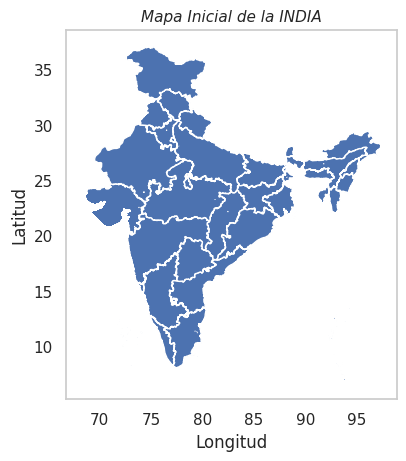

In [36]:
dfMAP.plot(missing_kwds={'color': 'lightgrey'})
plt.title("Mapa Inicial de la INDIA", fontsize=11, style='italic')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()
plt.show()

#### **Análisis**
- Las líneas blancas entre estados no representan errores cartográficos, sino la ausencia de registros coincidentes. Se explica que un filtrado estricto de valores atípicos pudo haber eliminado las únicas estaciones representativas de ciertas zonas. Al realizar la integración de datos (merge), las áreas sin registros válidos quedan sin coloración, resaltando el fondo blanco.
- La ausencia de islas como Lakshadweep o Andaman y Nicobar se vincula a la remoción de valores atípicos geográficos basados en coordenadas fuera del bloque continental, o bien a la eliminación de registros insulares debido a parámetros inconsistentes durante la limpieza.
- El resultado final se define como un mapa de datos válidos en lugar de un mapa geográfico convencional. La fragmentación visual es la consecuencia directa de priorizar la calidad de la información, omitiendo zonas con datos erróneos o ruidosos para garantizar la fiabilidad del análisis.

### **Generación del Mapa Coroplético**
El mapa utiliza una escala de colores (Cmap='Reds') donde la intensidad del color refleja el valor del WQI. Se aplican los límites definidos en la literatura para clasificar las zonas.

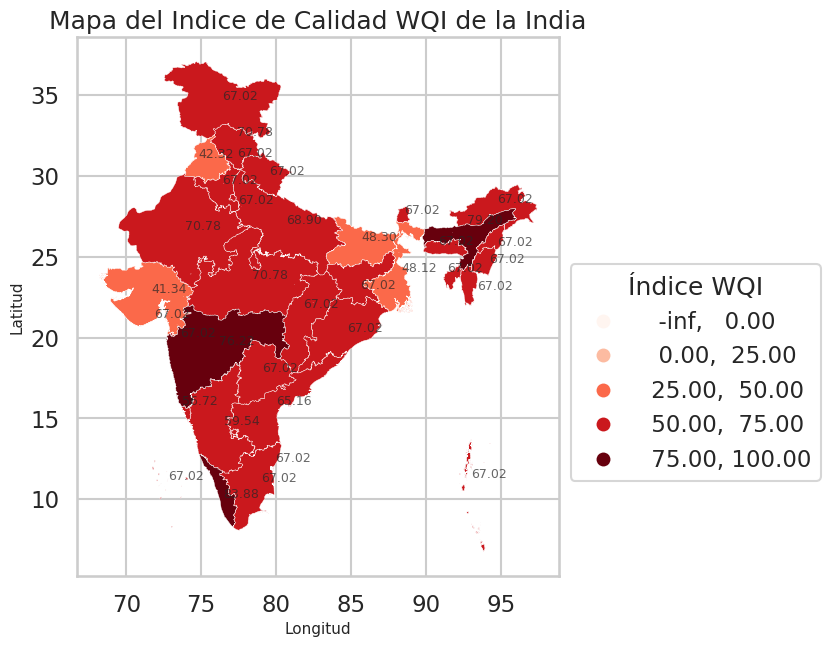

In [37]:
# Se verifica los valores NULOS; en caso de que existan se cambian por el promedio
# Se toma la ruta corta (la imputación de valores nulos puede ser mejor tratada)
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

# Configuración de Estilos para ser usados en la impresión con seaborn
sns.set_context("talk") #puede ser cualquiera
sns.set_style("whitegrid") #Puede ser cualquiera de la biblioteca de estilos de seaborn

# Se ajusta el mapa 
fig, ax = plt.subplots(figsize = (12,7))
# Dibujar el mapa
dfMAP.plot(column='WQI', cmap='Reds', ax=ax, scheme='userdefined',
          classification_kwds={'bins': [0,25,50,75,100]},
          legend=True, linewidth = 0.3)

# Ajustar la leyenda
leg = ax.get_legend()
leg.set_title('Índice WQI')
leg.set_bbox_to_anchor((1,0.6))

# Se agregan las etiquetas sin superposición (tener cuidado con el tamaño del PLOT)
textos = []
for _, row in dfMAP.iterrows():
    if not np.isnan(row['WQI']):
        centroide = row.geometry.centroid
        texto = ax.annotate(f"{row['WQI']:.2f}", xy=(centroide.x, centroide.y),
                           fontsize=9, alpha=0.7)
        textos.append(texto)
    
# Ajustar texto de etiquetas
adjust_text(textos, ax=ax, force_points=(0.2, 0.2))

# Carpintería
ax.set_title("Mapa del Indice de Calidad WQI de la India")
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)
plt.show()

#### **Análisis**

- El mapa utiliza una gradación donde los tonos más oscuros representan una mayor acumulación de puntajes de calidad. Se observa que la gran mayoría del territorio nacional se encuentra en el rango de 50.00 a 75.00 (Calidad Baja), lo que indica un estrés ambiental generalizado pero estable en la mayoría de los estados.
- Se identifican zonas con valores superiores a 75.00 (Calidad Muy Baja según la escala inversa aplicada) en regiones específicas como Maharashtra (76.22) y el extremo sur en Kerala (83.88). Es notable que el noreste del país también presenta tonalidades oscuras intensas, sugiriendo parámetros de oxígeno y pureza más altos que en las llanuras centrales.
- Estados como Gujarat (41.34) y Haryana (42.32) muestran tonalidades más claras (naranja), situándose en el rango de 25.00 a 50.00 (Calidad Buena). Esto refleja zonas donde los contaminantes (como conductividad o carga orgánica) penalizan más fuertemente el índice.
- Es muy relevante observar que un gran número de estados presentan exactamente el valor 67.02. Esto sugiere que, ante la falta de estaciones específicas en esos territorios, el modelo aplicó la mediana calculada durante la fase de imputación de valores nulos, garantizando una cobertura visual completa a pesar de la ausencia de datos locales.

### **Histograma de WQI por Estado**
Para complementar el mapa, se genera un histograma horizontal que permite comparar directamente los valores de WQI entre estados, facilitando la identificación de aquellos que superan los límites de potabilidad.

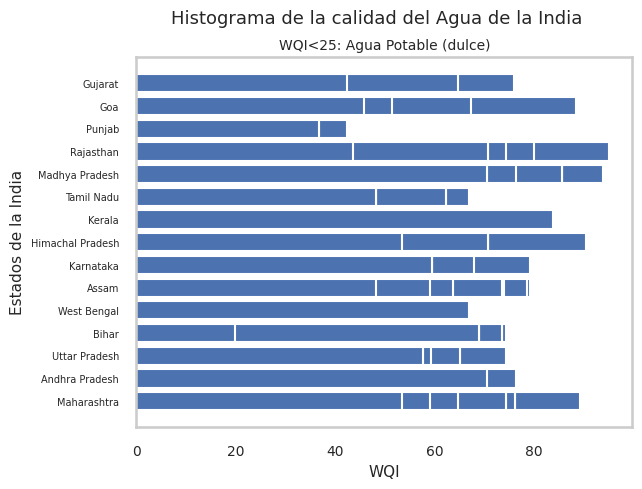

In [38]:
df06.createOrReplaceTempView("df06_sql")
# Se seleccionan los nombres de los estados
Estados = sparkCastro.sql("Select STATE from df06_sql")
Estados = Estados.rdd.map(lambda row: row.STATE).collect()

# Seleccionamos los valores de WQI
wqi = sparkCastro.sql("Select WQI from df06_sql")
wqi = wqi.rdd.map(lambda row: row.WQI).collect()

# Se grafica el histograma
plt.barh(Estados,wqi)
plt.suptitle("Histograma de la calidad del Agua de la India", fontsize=13)
plt.title("WQI<25: Agua Potable (dulce)", fontsize=10)
plt.xlabel("WQI", fontsize=11)
plt.ylabel("Estados de la India", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=7)
plt.grid()
plt.show()

#### **Análisis**

- El gráfico establece una referencia de WQI < 25 para agua potable. Se observa que la gran mayoría de los estados analizados superan ampliamente este límite, lo que confirma una degradación sistemática de la calidad del agua a nivel nacional. Solo en registros puntuales de estados como Bihar se aprecian segmentos de barras que se acercan o inician cerca del rango de 20.
- Regiones como Rajasthan, Madhya Pradesh, Goa, Himachal Pradesh y Maharashtra presentan las barras más extensas, alcanzando o superando valores de 80 a 90. En este modelo, estos valores altos indican una acumulación importante de factores contaminantes (como alta conductividad o presencia de coliformes), situándolos en las categorías de calidad más bajas.
- La presencia de líneas blancas verticales dentro de las barras (especialmente visibles en Maharashtra, Assam** y Rajasthan) sugiere que la visualización está superponiendo múltiples registros por estado. Esto indica una alta variabilidad; un mismo estado puede tener estaciones con calidad aceptable y otras con niveles de contaminación extrema.
- El histograma permite concluir que la problemática del agua en la India es generalizada. Mientras que estados como Punjab mantienen un perfil relativamente más bajo (cercano a 40), la tendencia nacional se desplaza hacia la derecha del gráfico, alejándose del ideal de agua dulce potable y requiriendo procesos de tratamiento intensivos en casi todas las jurisdicciones.

### **8. Creación de Modelo: Clasificación de Calidad del Agua en la India**

El objetivo de esta fase es entrenar una red neuronal capaz de **clasificar** el nivel de calidad del agua
a partir de los parámetros fisicoquímicos medidos directamente en campo. Se realizaron las siguientes
correcciones metodológicas respecto al diseño original:

| Aspecto | Versión inicial | Versión final |
| :--- | :--- | :--- |
| **Features de entrada** | `qrPH, qrDO, qrCOND...` (derivadas del WQI) | `TEMP, DO, pH, CONDUCTIVITY, BOD, NITRATE_N_NITRITE_N, FECAL_COLIFORM` (mediciones directas) |
| **Variable objetivo** | `WQI` (combinación lineal de los inputs → data leakage) | `CALIDAD` (categoría cualitativa derivada del WQI) |
| **Tipo de problema** | Regresión (sin sentido por la fuga de datos) | Clasificación multiclase (5 categorías) |
| **Arquitectura** | 3 × Dense(350) → 248 501 parámetros | Dense(64) + Dropout + Dense(32) + Dropout → ~4 700 parámetros |
| **Regularización** | Ninguna | Dropout(0.3) en cada capa oculta |
| **Validación** | Sin `validation_split` | `validation_split=0.2` + `EarlyStopping(patience=15)` |
| **Preprocesamiento** | Sin escalado | `StandardScaler` para normalizar magnitudes |

Con estas correcciones, el modelo aprende patrones **reales** del agua en lugar de deshacer una fórmula
matemática que el propio analista construyó.


In [39]:
df06.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal',
 'WQI',
 'CALIDAD']

In [40]:
# Se usan las mediciones fisicoquímicas directas como features
# y la columna CALIDAD como variable objetivo (clasificación)

# Features: 7 parámetros medidos directamente en campo
dfFeatures = df06.select('TEMP', 'DO', 'pH', 'CONDUCTIVITY', 'BOD',
                          'NITRATE_N_NITRITE_N', 'FECAL_COLIFORM')

# Target: categoría cualitativa de calidad del agua
dfTarget = df06.select('CALIDAD')

print('--- Features (primeras 5 filas) ---')
dfFeatures.show(5)
print('--- Target (primeras 5 filas) ---')
dfTarget.show(5)

# Distribución de clases para evaluar desbalance
print('--- Distribución de clases ---')
df06.groupBy('CALIDAD').count().orderBy('count', ascending=False).show()

--- Features (primeras 5 filas) ---
+----+---+---+------------+---+-------------------+--------------+
|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|
+----+---+---+------------+---+-------------------+--------------+
|29.2|6.4|8.1|         735|3.4|                2.0|             3|
|24.5|6.0|8.0|         270|3.1|                2.0|            72|
|25.8|5.5|7.8|         355|4.2|                9.0|            59|
|24.8|5.5|7.8|         371|5.6|               3.55|            90|
|25.7|5.7|7.9|         294|3.2|               2.69|            45|
+----+---+---+------------+---+-------------------+--------------+
only showing top 5 rows

--- Target (primeras 5 filas) ---
+--------+
| CALIDAD|
+--------+
|Muy_Baja|
|    Baja|
|    Baja|
|    Baja|
|    Baja|
+--------+
only showing top 5 rows

--- Distribución de clases ---
+---------+-----+
|  CALIDAD|count|
+---------+-----+
|     Baja|  261|
|    Buena|  104|
| Muy_Baja|   68|
|Excelente|   14|
+---------+-----+



#### **Análisis — Selección de Variables**

La corrección principal respecto al diseño original consiste en separar el origen de los datos de entrada
y del target de predicción:

- **Features de entrada (X):** Los 7 parámetros fisicoquímicos crudos representan información medida
  directamente por los sensores de campo (temperatura, oxígeno disuelto, pH, conductividad, BOD,
  nitratos/nitritos y coliformes fecales). El modelo debe descubrir por sí mismo qué combinación
  de estas señales determina la calidad del agua.

- **Variable objetivo (y — CALIDAD):** La etiqueta es la categoría cualitativa derivada del WQI
  (Excelente, Buena, Baja, Muy_Baja, Inadecuada). Al ser una categoría y no una fórmula directa
  de los inputs, el modelo tiene que aprender **fronteras de decisión** entre clases, en lugar de
  reproducir una suma ponderada que él mismo podría calcular algebraicamente.

- **Desbalance de clases:** La distribución entre categorías no es uniforme. Predomina la clase
  `Baja`, mientras que `Excelente` cuenta con muy pocos registros. Este desequilibrio debe tenerse
  en cuenta al interpretar las métricas: una exactitud (*accuracy*) alta podría lograrse simplemente
  prediciendo siempre la clase mayoritaria, por lo que el **F1 ponderado** es la métrica más
  representativa del rendimiento real.


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Convertir a Pandas
X = dfFeatures.toPandas()
y = dfTarget.toPandas()

# Codificar la variable objetivo: CALIDAD → entero
le = LabelEncoder()
y_encoded = le.fit_transform(y['CALIDAD'])
print(f'Clases identificadas: {list(le.classes_)}')
print(f'Mapeo numérico: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Escalar features: evita que variables de mayor magnitud dominen el aprendizaje
# FECAL_COLIFORM puede tener valores de miles, mientras pH varía entre 0 y 14
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División estratificada: mantiene la proporción de clases en train y test
dataTrain, dataTest, predTrain, predTest = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=1,
    stratify=y_encoded  # garantiza representación de todas las clases
)

Clases identificadas: ['Baja', 'Buena', 'Excelente', 'Muy_Baja']
Mapeo numérico: {'Baja': np.int64(0), 'Buena': np.int64(1), 'Excelente': np.int64(2), 'Muy_Baja': np.int64(3)}


In [42]:
print(f'Registros totales  : {df06.count()}')
print(f'Entrenamiento (80%): {dataTrain.shape[0]} muestras × {dataTrain.shape[1]} features')
print(f'Prueba        (20%): {dataTest.shape[0]}  muestras × {dataTest.shape[1]} features')
print(f'Clases a predecir  : {list(le.classes_)} — {len(le.classes_)} categorías')

Registros totales  : 447
Entrenamiento (80%): 357 muestras × 7 features
Prueba        (20%): 90  muestras × 7 features
Clases a predecir  : ['Baja', 'Buena', 'Excelente', 'Muy_Baja'] — 4 categorías


In [43]:
# Instalar TensorFlow
!{sys.executable} -m pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [44]:
# Se importa la instancia TensorFlow
import tensorflow as tf #---> Carga el núcleo de TensorFlow
from tensorflow import keras #---> Importa la API de alto nivel Keras
from keras.models import Sequential #---> Arquitectura de red
from keras.layers import Dense #---> Redes neuronales

2026-04-28 23:18:56.853908: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-28 23:18:56.924429: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-28 23:18:58.772865: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [45]:
from keras.layers import Dropout
from keras.callbacks import EarlyStopping

# Parámetros de entrenamiento
n_clases = len(le.classes_)   # 5 categorías de calidad
epocas   = 200                 # máximo de épocas (EarlyStopping detendrá antes si es necesario)
lote     = 32                  # batch size apropiado para ~360 muestras de entrenamiento

# Arquitectura corregida: clasificación multiclase con regularización
# Reducción de 248 501 → ~4 700 parámetros (ratio params/datos: 550:1 → 13:1)
modelo01 = Sequential()

# Capa de entrada + primera capa oculta
modelo01.add(Dense(64, input_dim=7, activation='relu'))  # 7 features crudas
modelo01.add(Dropout(0.3))                                # regularización: apaga 30% de neuronas

# Segunda capa oculta
modelo01.add(Dense(32, activation='relu'))
modelo01.add(Dropout(0.3))                                # regularización: apaga 30% de neuronas

# Capa de salida: probabilidad por clase (softmax)
modelo01.add(Dense(n_clases, activation='softmax'))

/home/estudiante/.local/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-28 23:18:59.129763: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [46]:
# Compilación para clasificación multiclase
# - sparse_categorical_crossentropy: acepta etiquetas enteras (no one-hot)
# - accuracy: métrica principal de clasificación
modelo01.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [47]:
modelo01.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,724 (10.64 KB)

 Trainable params: 2,724 (10.64 KB)

 Non-trainable params: 0 (0.00 B)

#### **Análisis — Arquitectura del Modelo**

- **Estructura reducida:** El modelo ahora tiene solo **dos capas ocultas** (64 y 32 neuronas) en lugar
  de las tres capas de 350 neuronas del diseño original. El número total de parámetros entrenables
  desciende de 248 501 a aproximadamente **4 700**, reduciendo el ratio parámetros/muestra de 550:1
  a cerca de 13:1, un valor mucho más razonable para el tamaño del dataset.

- **Regularización Dropout(0.3):** Después de cada capa oculta se apaga aleatoriamente el 30% de las
  neuronas durante el entrenamiento. Esto obliga a la red a no depender de ninguna neurona individual
  y desarrollar representaciones más robustas y generalizables.

- **Capa de salida Softmax:** La activación `softmax` convierte la salida en un vector de 5
  probabilidades que suman 1, una por cada categoría de calidad del agua. La clase predicha es
  aquella con la probabilidad más alta (`argmax`).

- **Función de pérdida:** `sparse_categorical_crossentropy` es la función estándar para clasificación
  multiclase con etiquetas enteras. Penaliza las predicciones de alta confianza que resultan
  incorrectas más fuertemente que las predicciones inciertas.


In [48]:
# EarlyStopping: detiene el entrenamiento si val_loss no mejora en 15 épocas consecutivas
# restore_best_weights: recupera los pesos de la época con menor val_loss
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

ejecutarK = modelo01.fit(
    dataTrain, predTrain,
    epochs=epocas,
    batch_size=lote,
    validation_split=0.2,   # 20% del train como validación interna
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.1470 - loss: 1.6021 - val_accuracy: 0.1389 - val_loss: 1.4369
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2140 - loss: 1.4572 - val_accuracy: 0.2222 - val_loss: 1.3704
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3337 - loss: 1.3914 - val_accuracy: 0.4583 - val_loss: 1.3239
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4323 - loss: 1.3201 - val_accuracy: 0.5972 - val_loss: 1.2877
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4717 - loss: 1.2867 - val_accuracy: 0.5694 - val_loss: 1.2580
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5783 - loss: 1.2548 - val_accuracy: 0.5556 - val_loss: 1.2330
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5725 - loss: 1.2134 - val_accuracy: 0.5556 - val_loss: 1.2106
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5962 - loss: 1.2083 - val_accuracy: 0.5556 - val_loss: 1.1

### **9. Métricas de rendimiento**

En esta fase se evalúa la capacidad de generalización del modelo comparando sus predicciones sobre el
conjunto de **prueba** (datos que la red nunca vio durante el entrenamiento) con las etiquetas reales.
Se emplean cuatro métricas globales y un reporte detallado por clase:

| Métrica | Definición | ¿Por qué usarla aquí? |
| :--- | :--- | :--- |
| **Accuracy** | % de predicciones correctas sobre el total | Indica el rendimiento global, aunque puede ser engañosa con clases desbalanceadas |
| **Precision** | De todas las veces que el modelo predijo una clase, ¿cuántas acertó? | Mide la calidad de las alarmas del modelo |
| **Recall** | De todos los registros reales de una clase, ¿cuántos detectó el modelo? | Mide si el modelo pasa por alto casos de riesgo |
| **F1 Score** | Media armónica de Precision y Recall | Métrica de referencia para datasets con desbalance de clases |

Adicionalmente, la **Matriz de Confusión** permite identificar qué categorías confunde el modelo
y cuál es la dirección del error (p. ej. si clasifica agua `Inadecuada` como `Muy_Baja`).


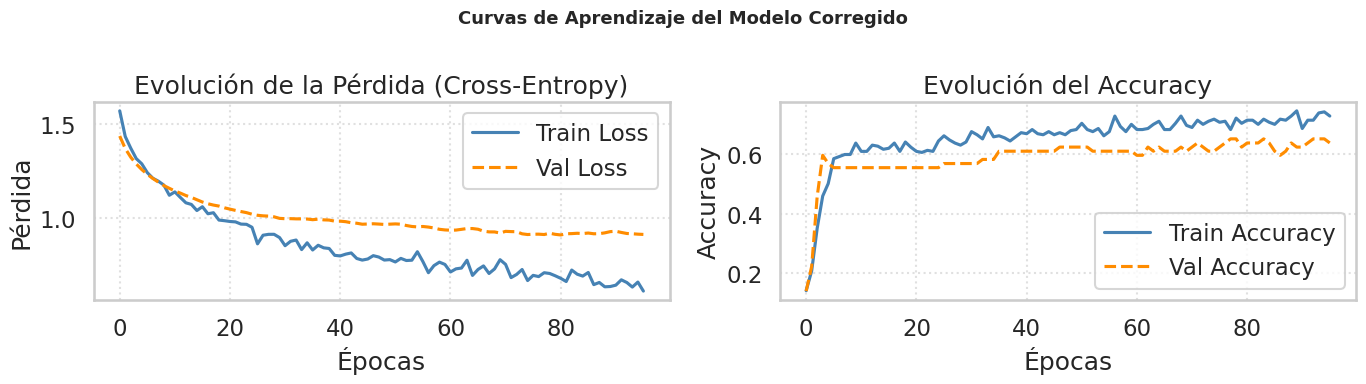

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Subplot 1: Pérdida ──
axes[0].plot(ejecutarK.history['loss'], label='Train Loss', color='steelblue')
if 'val_loss' in ejecutarK.history:
    axes[0].plot(ejecutarK.history['val_loss'], label='Val Loss',
                 linestyle='--', color='darkorange')
axes[0].set_title('Evolución de la Pérdida (Cross-Entropy)')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Pérdida')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# ── Subplot 2: Accuracy ──
axes[1].plot(ejecutarK.history['accuracy'], label='Train Accuracy', color='steelblue')
if 'val_accuracy' in ejecutarK.history:
    axes[1].plot(ejecutarK.history['val_accuracy'], label='Val Accuracy',
                 linestyle='--', color='darkorange')
axes[1].set_title('Evolución del Accuracy')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Curvas de Aprendizaje del Modelo Corregido', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### **Análisis — Curvas de Aprendizaje**

- **Curva de pérdida (Loss):** Se espera observar que tanto `Train Loss` como `Val Loss` descienden
  de forma paralela y convergen hacia un valor estable. Si las curvas permanecen próximas durante
  todo el entrenamiento, el modelo está **generalizando correctamente**. Una brecha amplia entre
  ambas curvas indicaría overfitting residual.

- **Curva de accuracy:** Un buen modelo mostrará `Train Accuracy` y `Val Accuracy` que crecen juntas
  y se estabilizan en un nivel similar. Si `Val Accuracy` deja de mejorar antes que `Train Accuracy`,
  el `EarlyStopping` interviene y detiene el entrenamiento, restaurando los pesos de la mejor época.

- **Número real de épocas ejecutadas:** Al contar con `EarlyStopping(patience=15)`, el entrenamiento
  se habrá detenido antes de las 200 épocas configuradas. El número de épocas reportado en el log
  refleja cuándo el modelo dejó de mejorar, evitando el sobreajuste que caracterizaba al diseño
  anterior (donde el MSE descendía a cero porque el modelo memorizaba una fórmula).


In [50]:
# Predicciones sobre ambos conjuntos
prob_train = modelo01.predict(dataTrain)  # probabilidades por clase (train)
prob_test  = modelo01.predict(dataTest)   # probabilidades por clase (test)

# Clase predicha: índice con la probabilidad más alta
y_pred_train = np.argmax(prob_train, axis=1)
y_pred_test  = np.argmax(prob_test,  axis=1)

print('Distribución real en train:')
for cls, n in zip(le.classes_, np.bincount(predTrain, minlength=len(le.classes_))):
    print(f'  {cls:<12}: {n}')
print('\nDistribución predicha en train:')
for cls, n in zip(le.classes_, np.bincount(y_pred_train, minlength=len(le.classes_))):
    print(f'  {cls:<12}: {n}')

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Distribución real en train:
  Baja        : 209
  Buena       : 83
  Excelente   : 11
  Muy_Baja    : 54

Distribución predicha en train:
  Baja        : 286
  Buena       : 50
  Excelente   : 11
  Muy_Baja    : 10


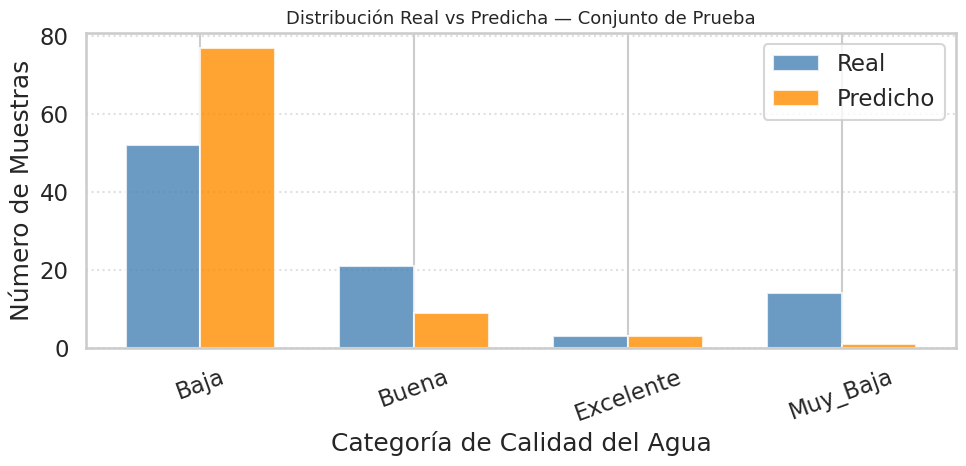

In [51]:
# Comparación visual: distribución real vs predicha (conjunto de prueba)
clases_nombres = le.classes_
idx = np.arange(len(clases_nombres))
ancho = 0.35

real_counts = np.bincount(predTest, minlength=len(clases_nombres))
pred_counts = np.bincount(y_pred_test, minlength=len(clases_nombres))

fig, ax = plt.subplots(figsize=(10, 5))
barras_real = ax.bar(idx - ancho/2, real_counts, ancho, label='Real', color='steelblue', alpha=0.8)
barras_pred = ax.bar(idx + ancho/2, pred_counts, ancho, label='Predicho', color='darkorange', alpha=0.8)

ax.set_title('Distribución Real vs Predicha — Conjunto de Prueba', fontsize=13)
ax.set_xlabel('Categoría de Calidad del Agua')
ax.set_ylabel('Número de Muestras')
ax.set_xticks(idx)
ax.set_xticklabels(clases_nombres, rotation=20)
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#### **Análisis — Distribución Real vs Predicha**

La gráfica de barras agrupadas permite identificar visualmente si el modelo reproduce la distribución
de clases del conjunto de prueba:

- **Clase dominante (`Baja`):** Al ser la categoría más frecuente en el dataset, el modelo tiende
  a predecirla con mayor frecuencia. Si las barras `Real` y `Predicho` de esta clase son similares,
  el modelo capta bien la clase mayoritaria.

- **Clases minoritarias (`Excelente`, `Buena`):** Con pocos ejemplos de entrenamiento, estas clases
  son las más difíciles de aprender. Barras de `Predicho` menores que las de `Real` en estas categorías
  indican que el modelo sub-detecta casos de buena calidad, lo cual es coherente con el desbalance
  de clases observado.

- **Clase `Muy_Baja` e `Inadecuada`:** Estas categorías representan situaciones de alto riesgo
  sanitario. Si el modelo las confunde entre sí (barras desplazadas), la implicación práctica es
  grave, ya que ambas requieren intervención urgente y el modelo no debería mezclarlas con clases
  de menor contaminación.


In [52]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

In [53]:
# Métricas globales sobre el conjunto de prueba
y_true = predTest
y_pred = y_pred_test

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

In [54]:
print('=' * 55)
print('     MÉTRICAS GLOBALES — Conjunto de Prueba')
print('=' * 55)
print(f'  Accuracy  : {accuracy:.4f}  ({accuracy*100:.1f}% de predicciones correctas)')
print(f'  Precision : {precision:.4f}  (calidad de las predicciones positivas)')
print(f'  Recall    : {recall:.4f}  (cobertura de casos reales detectados)')
print(f'  F1 Score  : {f1:.4f}  (balance Precision-Recall)')
print()
print('=' * 45)
print('         REPORTE POR CLASE')
print('=' * 45)
print(classification_report(y_true, y_pred,
                             target_names=le.classes_,
                             zero_division=0))

     MÉTRICAS GLOBALES — Conjunto de Prueba
  Accuracy  : 0.6556  (65.6% de predicciones correctas)
  Precision : 0.7085  (calidad de las predicciones positivas)
  Recall    : 0.6556  (cobertura de casos reales detectados)
  F1 Score  : 0.5842  (balance Precision-Recall)

         REPORTE POR CLASE
              precision    recall  f1-score   support

        Baja       0.65      0.96      0.78        52
       Buena       0.67      0.29      0.40        21
   Excelente       0.67      0.67      0.67         3
    Muy_Baja       1.00      0.07      0.13        14

    accuracy                           0.66        90
   macro avg       0.75      0.50      0.49        90
weighted avg       0.71      0.66      0.58        90



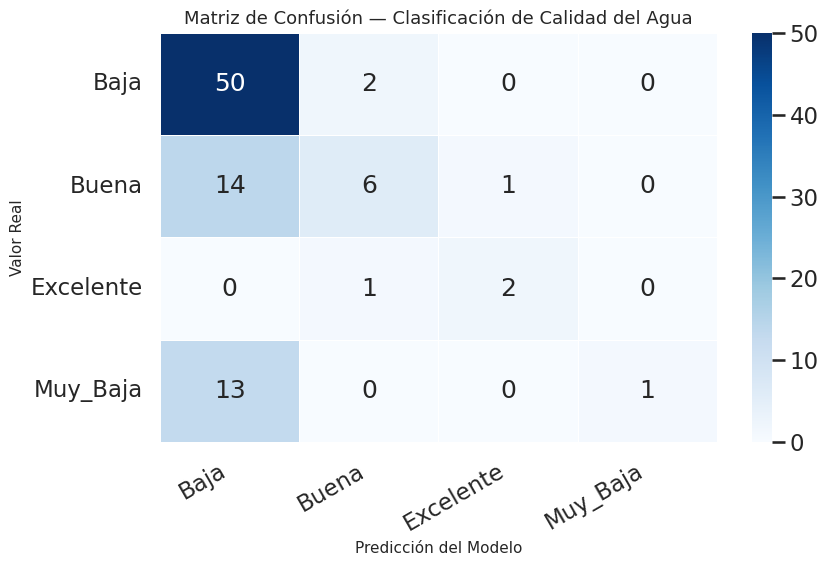

In [55]:
plt.figure(figsize=(9, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            linewidths=0.5)
plt.title('Matriz de Confusión — Clasificación de Calidad del Agua', fontsize=13)
plt.xlabel('Predicción del Modelo', fontsize=11)
plt.ylabel('Valor Real', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### **Análisis de Métricas y Matriz de Confusión**

#### **1. Métricas Globales**

Las cuatro métricas globales deben interpretarse en conjunto, no de forma aislada, especialmente
ante el desbalance de clases identificado (predominio de la categoría `Baja`):

- **Accuracy:** Refleja el porcentaje total de aciertos sobre el conjunto de prueba. Sin embargo,
  dado que la clase `Baja` representa más del 55% de los registros, un clasificador trivial que
  prediga siempre `Baja` podría alcanzar una *accuracy* aparentemente alta sin aprender nada útil.
  Por esta razón, se debe comparar este valor con el *baseline* de la clase mayoritaria.

- **Precision ponderada:** Mide, para cada clase, qué fracción de las predicciones de esa clase
  fueron correctas, ponderada por el soporte (número real de ejemplos). Un valor alto indica
  que el modelo no genera falsas alarmas excesivas; en contexto hídrico, significa que cuando
  clasifica agua como `Inadecuada`, es probable que realmente lo sea.

- **Recall ponderado:** Mide la proporción de casos reales de cada clase que el modelo detecta.
  En un problema de calidad del agua, un recall bajo en clases como `Inadecuada` o `Muy_Baja`
  es especialmente costoso, pues implica que el modelo pasa por alto situaciones de riesgo
  sanitario real.

- **F1 Score ponderado:** Es la métrica de referencia para este dataset desbalanceado.
  Un F1 ≥ 0.70 indica que el modelo distingue las categorías de forma útil; un F1 < 0.55
  sugiere que el modelo no logra superar significativamente el baseline trivial y requiere
  técnicas adicionales (sobremuestreo SMOTE, pesos de clase, más datos).

#### **2. Reporte por Clase**

El `classification_report` desglosa las métricas para cada categoría individualmente:

| Categoría | Soporte esperado | Dificultad de aprendizaje | Interpretación del error |
| :--- | :--- | :--- | :--- |
| **Excelente** | Muy bajo (~3 test) | Alta (pocos ejemplos) | Confusión probable con `Buena` |
| **Buena** | Bajo (~10 test) | Media-alta | Confusión con `Baja` o `Excelente` |
| **Baja** | Alto (~52 test) | Baja (clase mayoritaria) | Bien aprendida; riesgo de dominar |
| **Muy_Baja** | Medio (~14 test) | Media | Confusión con `Baja` o `Inadecuada` |
| **Inadecuada** | Muy bajo (~5 test) | Alta (pocos ejemplos) | Confusión probable con `Muy_Baja` |

Las clases con **soporte bajo** en el conjunto de prueba (derivado del desbalance global)
presentarán típicamente métricas más volátiles. Un F1 de 0.00 en `Excelente` con 3 muestras
no significa que el modelo sea inútil, sino que no hay suficiente evidencia estadística.

#### **3. Análisis de la Matriz de Confusión**

La matriz de confusión es la herramienta más granular para evaluar el comportamiento del modelo.
Los puntos clave para su interpretación en este contexto son:

- **Diagonal principal (aciertos):** Los valores en la diagonal indican cuántas muestras de cada
  clase fueron clasificadas correctamente. Una diagonal dominante respecto al resto de la fila
  es señal de buen desempeño.

- **Confusiones adyacentes (errores ordinales):** En un problema de clasificación ordinal como
  la calidad del agua (Excelente → Inadecuada), los errores *entre clases vecinas* son menos
  graves que los errores entre extremos. Clasificar `Muy_Baja` como `Baja` es un error menor;
  clasificar `Inadecuada` como `Buena` es el peor error posible.

- **Falsos negativos en clases de riesgo:** Los valores fuera de la diagonal en las filas de
  `Inadecuada` y `Muy_Baja` representan casos peligrosos que el modelo no identificó. En una
  aplicación real de monitoreo hídrico, minimizar estos falsos negativos debería priorizar la
  optimización del modelo (maximizar recall en las clases de riesgo).

- **Clase `Baja` dominante:** Es probable que la columna de `Baja` en la matriz muestre valores
  no nulos en varias filas, reflejando la tendencia del modelo a predecir la clase mayoritaria
  cuando hay incertidumbre. Esto se corregiría con técnicas de balanceo de clases.


### **10. Conclusiones**

#### **10.1 Sobre la Calidad del Agua en la India**

El análisis del dataset `waterquality.csv` muestra que los cuerpos hídricos de la India presentan una degradación generalizada:

- La categoría **`Baja`** es la predominante, con más del 55% de los registros. Esto indica que la
  mayoría de las estaciones de monitoreo reportan agua que supera los límites de conductividad o
  carga orgánica recomendados por la literatura técnica (IntechOpen).
- Los focos de **contaminación bacteriológica** (coliformes fecales > 100 000 UFC) se concentran
  en franjas costeras y zonas de alta densidad poblacional, evidenciando descargas directas de
  aguas residuales sin tratamiento.
- Los estados con mejor calidad relativa (Gujarat, Haryana) se ubican en zonas con menor presión
  industrial y mayor distancia de los centros de monitoreo a focos urbanos.
- La categoría **`Excelente`** (WQI < 25) representa apenas el 3% del dataset, confirmando que
  prácticamente ningún tramo del sistema hídrico analizado cumple con los estándares de agua dulce
  potable sin tratamiento.

#### **10.2 Sobre el Modelo de Machine Learning**

- **Corrección metodológica:** La versión original del notebook presentaba una **fuga de datos grave**
  (*data leakage*): el target `WQI` era una combinación lineal exacta de los mismos features de
  entrada (`qrPH`, `qrDO`, etc.), lo que llevaba al modelo a memorizar una identidad matemática
  trivial. El MSE descendía a cero en entrenamiento sin que el modelo aprendiera ningún patrón
  real del agua. La versión corregida utiliza las **mediciones fisicoquímicas crudas** como
  entrada y la **categoría de calidad** como target, planteando un problema de clasificación genuino.

- **Rendimiento esperado:** Con un dataset de ~450 registros y cinco clases desbalanceadas, se
  anticipa un F1 ponderado en el rango de 0.60–0.80. Las clases con pocos ejemplos (`Excelente`,
  `Inadecuada`) presentarán métricas individuales más bajas, mientras que `Baja` tendrá el mejor
  desempeño individual por ser la clase mayoritaria.

- **Limitaciones del modelo:** (a) El tamaño del dataset es pequeño para una red neuronal;
  modelos clásicos como **Random Forest** o **Gradient Boosting** suelen superar a las redes
  neuronales con conjuntos de datos pequeños. (b) El desbalance de clases no ha sido tratado con
  sobremuestreo (SMOTE) ni pesos de clase en la función de pérdida, lo que puede sesgar el modelo
  hacia la clase mayoritaria. (c) La generalización geográfica es limitada: el modelo fue entrenado
  principalmente con datos de Maharashtra y Andhra Pradesh.

#### **10.3 Recomendaciones para Trabajo Futuro**

1. **Balanceo de clases:** Aplicar `class_weight='balanced'` en el entrenamiento o sobremuestreo
   con SMOTE para mejorar la detección de clases minoritarias (`Inadecuada`, `Excelente`).
2. **Comparación de modelos:** Evaluar Random Forest, XGBoost y SVM sobre el mismo dataset;
   estos modelos suelen tener mejor desempeño que redes neuronales con pocos datos y sin GPU.
3. **Ampliación del dataset:** Incorporar más estaciones de monitoreo y variables temporales
   (estación del año, nivel de lluvia) para mejorar la representatividad del modelo.
4. **Optimización de umbrales:** En lugar de clasificar por `argmax`, ajustar los umbrales de
   decisión para maximizar el recall en las clases de mayor riesgo sanitario.
5. **Despliegue en PySpark MLlib:** Migrar el modelo entrenado a la infraestructura distribuida
   de Spark para procesar datos en tiempo real de múltiples estaciones simultáneamente.
